In [4]:
import image
import neuropythy as ny

# Load in a map which should be the fsaverage template that I'm using to project my volumetric maps to
sub = ny.freesurfer_subject('/Applications/freesurfer/7.3.2/subjects/fsaverage')  # explicit dir
(lh_retino, rh_retino) = ny.vision.predict_retinotopy(sub)



In [5]:

(lh_retino, rh_retino) = ny.vision.predict_retinotopy(sub)

tuple([sorted(retino.keys()) for retino in (lh_retino, rh_retino)])

(all(len(v) == sub.lh.vertex_count for v in lh_retino.values()),
 all(len(v) == sub.rh.vertex_count for v in rh_retino.values()))

(True, True)

In [8]:
mdl = ny.vision.retinotopy_model('benson17', 'lh')  # or 'rh'
mdl.area_name_to_id

pmap({'V3a': 12, 'VO1': 5, 'V2': 2, 'LO1': 7, 'TO2': 10, 'VO2': 6, 'TO1': 9, 'V3': 3, 'V1': 1, 'V3b': 11, 'hV4': 4, 'LO2': 8})

In [3]:
from nilearn.maskers import SurfaceLabelsMasker
from nilearn.surface import SurfaceImage
from nilearn.datasets import load_fsaverage
from pathlib import Path
import neuropythy as ny 
import nibabel as nib 
import pandas as pd 



cache_dir = Path(ny.library_path()) / "data"
cache_atlas_dir = cache_dir / 'fsaverage/surf/'

mdl = ny.vision.retinotopy_model('benson14', 'rh')
idxs = [idx - 1 for idx in mdl.area_id_to_name.keys()]
labels = ['Background'] + [lab for lab in mdl.area_id_to_name.values() if lab is not None]
lut = pd.DataFrame({"index": idxs, "name": labels})


lh_benson_path = cache_atlas_dir / "lh.benson14_varea.v4_0.mgz"
rh_benson_path = cache_atlas_dir / "rh.benson14_varea.v4_0.mgz"
lh_benson = nib.load(lh_benson_path)
rh_benson = nib.load(rh_benson_path)

if Path(cache_atlas_dir / "benson14_varea.v4_0_mesh.gii").exists():
    mesh = {
    "left": output_dir / "surface_image_mesh_hemi-L.gii",
    "right": output_dir / "surface_image_mesh_hemi-R.gii",
    }
    data = {
        "left": output_dir / "surface_image_data_hemi-L.gii",
        "right": output_dir / "surface_image_data_hemi-R.gii",
    }
    
    labels_img = SurfaceImage(
        mesh=mesh,
        data=data,
    )

fsaverage = load_fsaverage("fsaverage7")

labels_img = SurfaceImage(
    mesh=fsaverage["pial"],
    data={
        "left": lh_benson.get_fdata().squeeze(),
        "right": rh_benson.get_fdata().squeeze(),
    },
)

labels_img.mesh.to_filename(cache_atlas_dir / "benson14_varea.v4_0_mesh.gii")
labels_img.data.to_filename(cache_atlas_dir / "benson14_varea.v4_0_data.gii")

labels_masker = SurfaceLabelsMasker(
    labels_img=labels_img, lut=lut, verbose=1
).fit()



[load_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
[SurfaceLabelsMasker.fit] Loading regions from <SurfaceImage (327684,)>
[SurfaceLabelsMasker.fit] Finished fit


In [13]:
from nilearn.datasets import fetch_surf_fsaverage

fs = fetch_surf_fsaverage()
nib.load(fs["pial_left"]).agg_data()


array([[    0,  2564,  2562],
       [    0,  2562,  2565],
       [    0,  2565,  2567],
       ...,
       [10241,  9918,  2454],
       [10161,  9918, 10241],
       [10161,    11,  9918]], dtype=int32)

In [45]:
import nibabel as nib

# img = nib.load('/Users/zach/2025_RA/matthias/eyemove_and_sleep/SleepMReye/benson/mri/benson14_varea.mgz')
l_img = nib.load("/Users/zach/.virtualenvs/testmreyemove/lib/python3.11/site-packages/neuropythy/lib/data/fsaverage/surf/lh.benson14_varea.v4_0.mgz")
r_img = nib.load("/Users/zach/.virtualenvs/testmreyemove/lib/python3.11/site-packages/neuropythy/lib/data/fsaverage/surf/rh.benson14_varea.v4_0.mgz")
l_img.get_fdata().sum() + r_img.get_fdata().sum()

170968.0

In [46]:
img = nib.load('/Users/zach/2025_RA/matthias/eyemove_and_sleep/SleepMReye/benson/mri/benson14_varea.mgz')
img.get_fdata().sum()


174191.0

In [50]:
import pandas as pd

mdl = ny.vision.retinotopy_model('benson14', 'rh')  # or 'rh'
idxs = [idx - 1 for idx in mdl.area_id_to_name.keys()] 
labels = ['Background'] + [lab for lab in mdl.area_id_to_name.values() if lab is not None]
lut = pd.DataFrame({"index": idxs, "name": labels})
lut

,index,name
0,0,Background
1,1,V1
2,2,V2
3,3,V3
4,4,hV4
5,5,VO1
6,6,VO2
7,7,LO1
8,8,LO2
9,9,TO1


In [15]:
from pathlib import Path
import neuropythy as ny
import pandas as pd
import nibabel as nib
from nilearn.surface import SurfaceImage
from nilearn.datasets import load_fsaverage

mdl = ny.vision.retinotopy_model('benson14', 'rh')
idxs = [idx - 1 for idx in mdl.area_id_to_name.keys()]
labels = ['Background'] + [lab for lab in mdl.area_id_to_name.values() if lab is not None]
lut = pd.DataFrame({"index": idxs, "name": labels})

lut

,index,name
0,0,Background
1,1,V1
2,2,V2
3,3,V3
4,4,hV4
5,5,VO1
6,6,VO2
7,7,LO1
8,8,LO2
9,9,TO1


In [11]:
# First let's load the Benson atlas into a SurfaceImage and get the labels 

from pathlib import Path 
import neuropythy as ny
import pandas as pd
import nibabel as nib
from nilearn.surface import SurfaceImage
from nilearn.datasets import load_fsaverage

cache_dir = Path(ny.library_path()) / "data"
cache_atlas_dir = cache_dir / 'fsaverage/surf/'

mdl = ny.vision.retinotopy_model('benson14', 'rh')
idxs = [idx - 1 for idx in mdl.area_id_to_name.keys()]
labels = ['Background'] + [lab for lab in mdl.area_id_to_name.values() if lab is not None]
lut = pd.DataFrame({"index": idxs, "name": labels})

lh_benson_path = cache_atlas_dir / "lh.benson14_varea.v4_0.mgz"
rh_benson_path = cache_atlas_dir / "rh.benson14_varea.v4_0.mgz"
lh_benson = nib.load(lh_benson_path)
rh_benson = nib.load(rh_benson_path)

if Path(cache_atlas_dir / "benson14_varea.v4_0_mesh_hemi-L.gii").exists():
    mesh = {
        "left": cache_atlas_dir / "benson14_varea.v4_0_mesh_hemi-L.gii",
        "right": cache_atlas_dir / "benson14_varea.v4_0_mesh_hemi-R.gii",
    }
    data = {
        "left": cache_atlas_dir / "benson14_varea.v4_0_data_hemi-L.gii",
        "right": cache_atlas_dir / "benson14_varea.v4_0_data_hemi-R.gii",
    }

    labels_img = SurfaceImage(
        mesh=mesh,
        data=data,
    )
    # return Bunch(maps=labels_img, labels=labels, lut=lut)

fsaverage = load_fsaverage("fsaverage7")

labels_img = SurfaceImage(
    mesh=fsaverage["pial"],
    data={
        "left": lh_benson.get_fdata().squeeze(),
        "right": rh_benson.get_fdata().squeeze(),
    },
)

labels_img.mesh.to_filename(cache_atlas_dir / "benson14_varea.v4_0_mesh.gii")
labels_img.data.to_filename(cache_atlas_dir / "benson14_varea.v4_0_data.gii")


[load_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage


In [2]:
# Now I want to see what the borders of V1,2, and 3 look like overlaid on our group level maps for wake and sleep

""" First load the data with mrio """

from mreyemove.analysis.glm.cli import construct_desc
from mreyemove.analysis.glm.config import GLMConfig
from SleepMReye.sleepmreye.sleep_mrio import SleepMRIO

mrio = SleepMRIO(
    bids_root="/Users/zach/2025_RA/matthias/bids_sleepmreye",
    tr=2.1,
    task="sleep",
    load_signal=True,
    desc_add="clean",
    ignore_boundary_trs=0,
    load_eog=False,
    data_dir="/Users/zach/2025_RA/matthias/bids_sleepmreye/derivatives/fmriprep"
)
config = GLMConfig.from_yaml("/Users/zach/2025_RA/matthias/eyemove_and_sleep/SleepMReye/sleepmreye/designs/original_sleep_atlas.yml")
desc_add = construct_desc(dataset=mrio, config=config)
desc_add = f"{desc_add}-{config.second_level.method}"



[load_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
[fetch_surf_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
[check_mesh_is_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
[check_mesh_is_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage


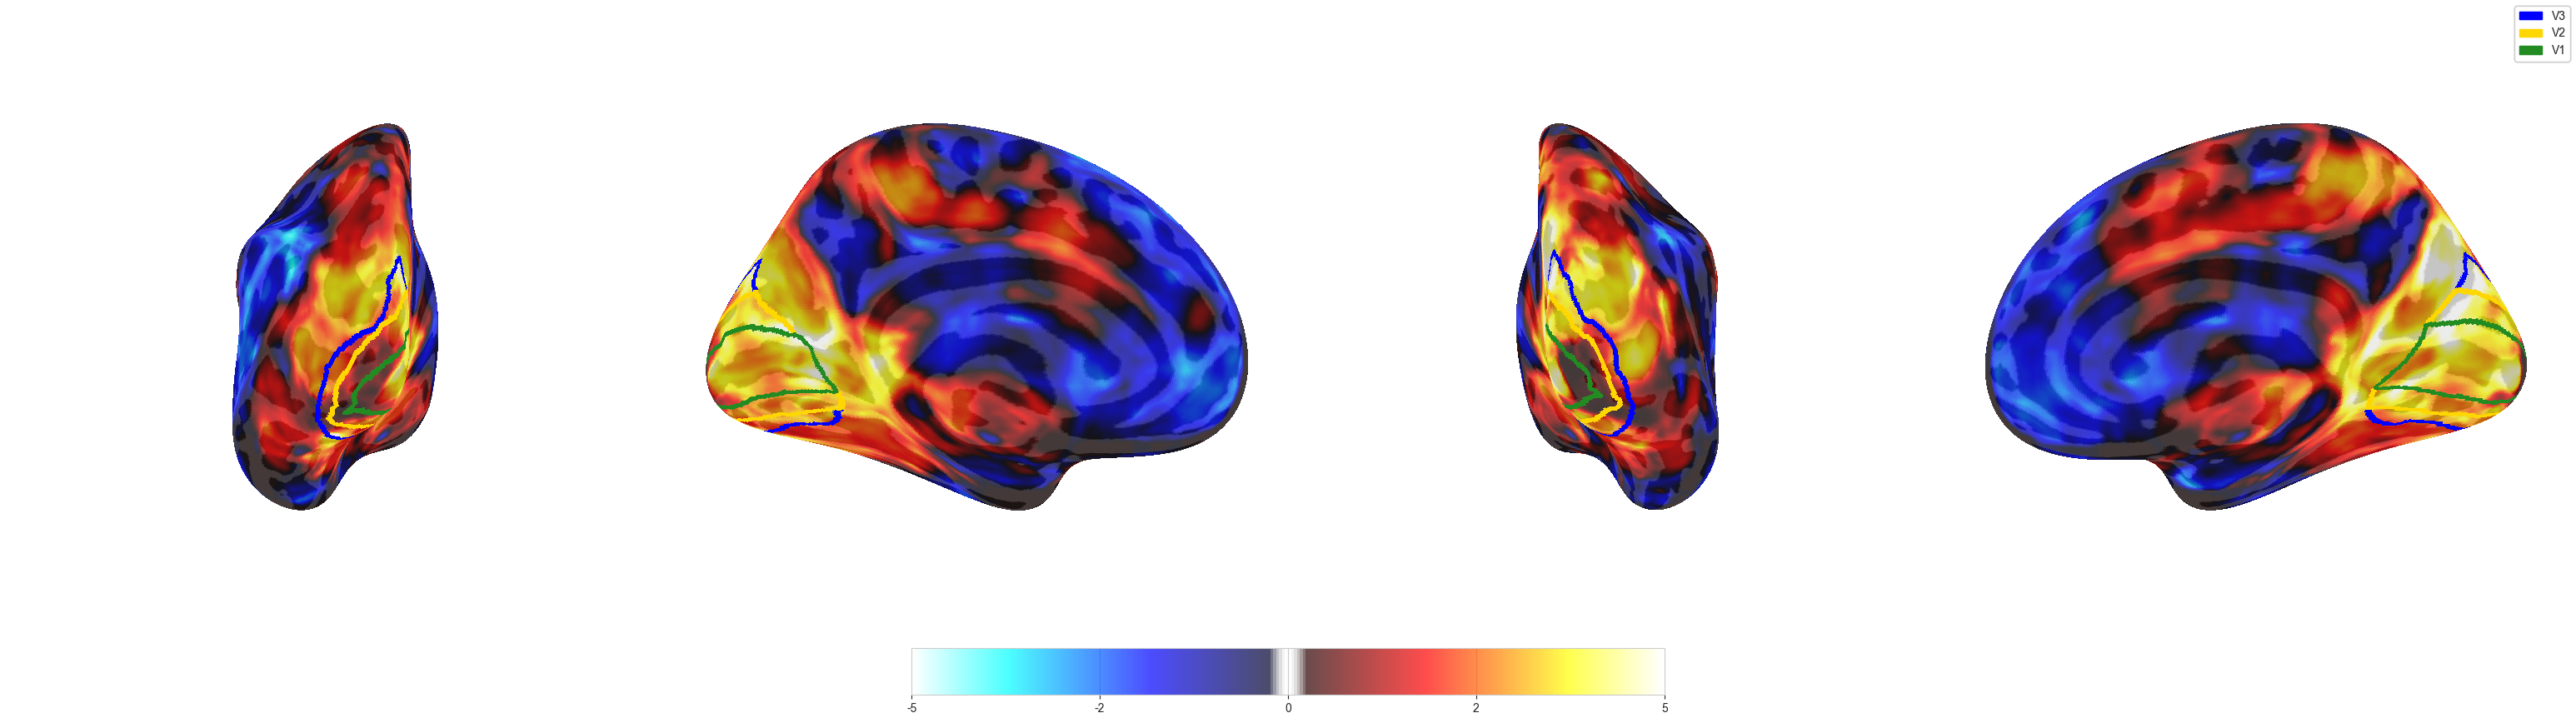

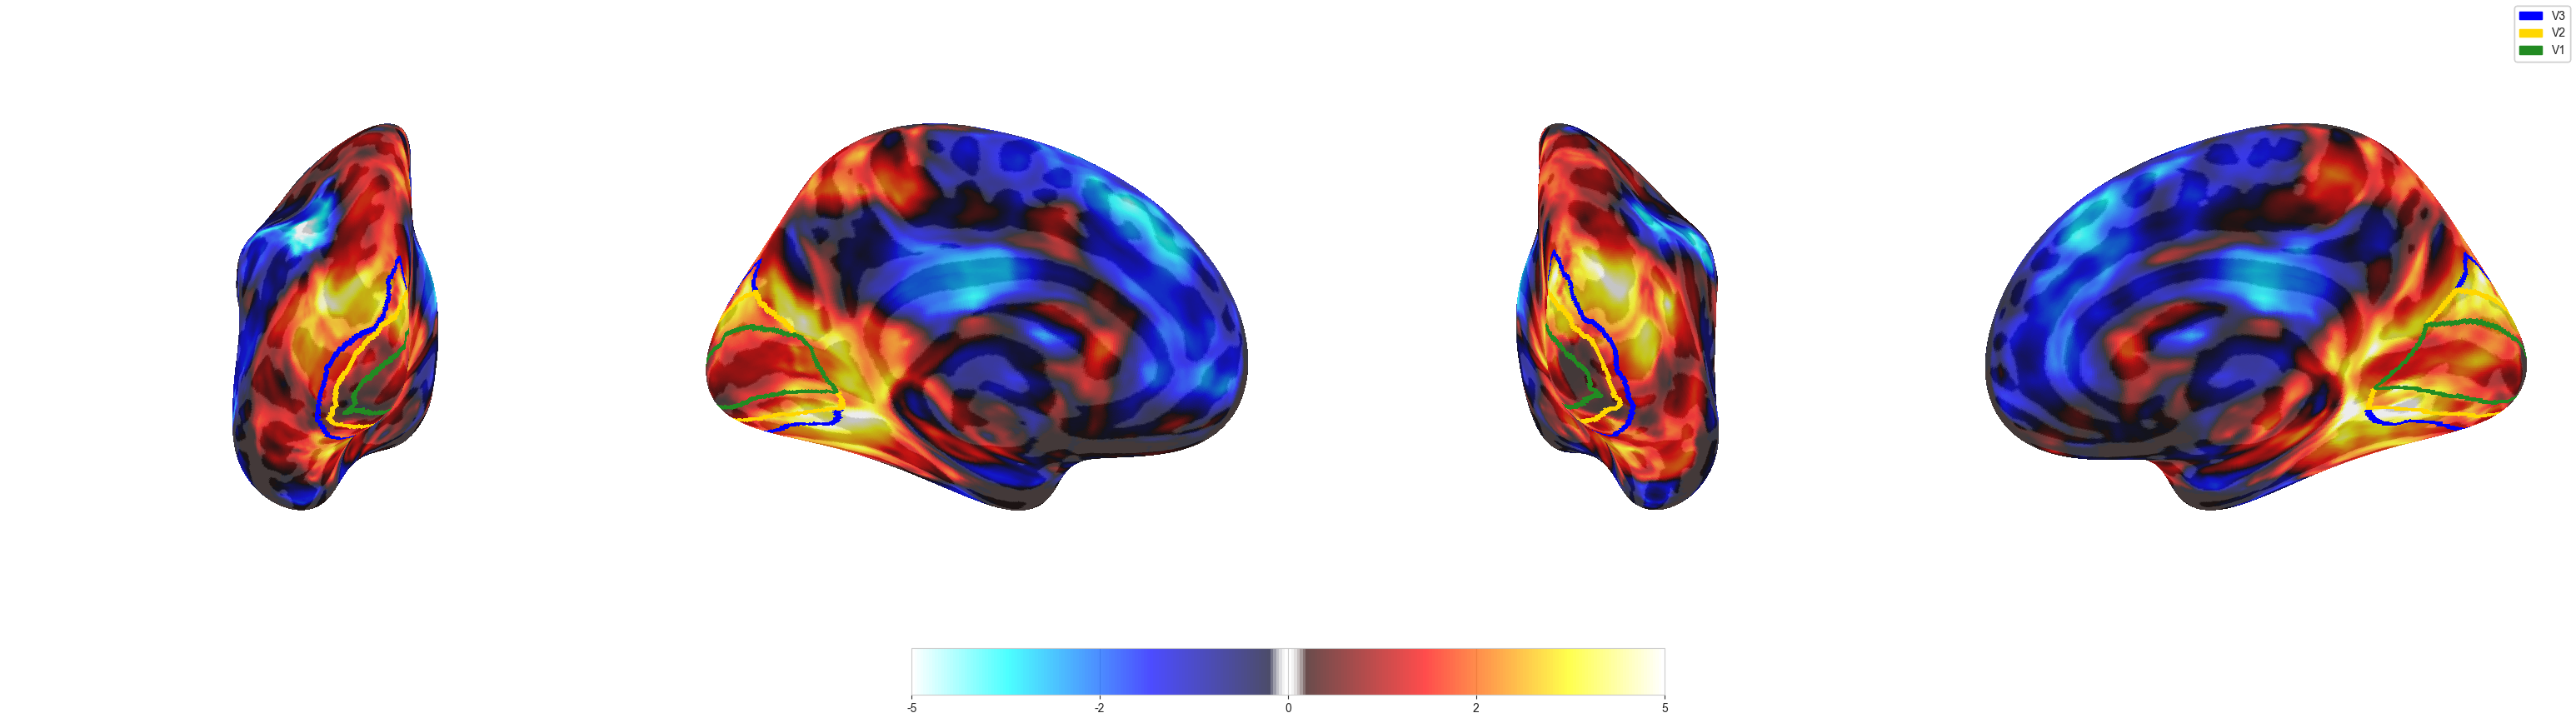

In [25]:
# Now do the plotting
# I'm using posterior and medial views to really focus on the occipital pole and its surrounds 

from mreyemove.analysis.glm.atlas import fetch_atlas
from nilearn.datasets import load_fsaverage
atlas = fetch_atlas("benson")

from mreyemove.plotting.glm_surface import plot_img_on_surf_with_contour
from nilearn import image, datasets
from mreyemove.plotting.glm import custom_cmap

surf_mesh = "fsaverage7"
fsaverage7 = datasets.fetch_surf_fsaverage(mesh=surf_mesh)
    
roi_surf = {}
proj_kwargs = dict(interpolation="linear", radius=3.0, kind="line", n_samples=10)

contrasts = ("mreyemove_W", "mreyemove_S")
contrast_map = {contrast: mrio.load_FLAME_result(contrast=contrast, desc_add=desc_add)[0].t_stat for contrast in contrasts}
panels = [
        ("left", "posterior"),
        ("left", "medial"),
        ("right", "posterior"),
        ("right", "medial"),
    ]
for contrast in contrasts:
    t_masked = contrast_map[contrast]
    
    plot_img_on_surf_with_contour(
        surf_mesh=surf_mesh,
        stat_map=t_masked,
        roi_map=atlas.maps.data.parts,
        levels=[3,2,1],
        labels=["V3", "V2", "V1"],
        contour_width=2,
        colors=["blue", "gold", "forestgreen"],
        vmin=-5, vmax=5,
        cmap=custom_cmap(),
        inflate=True,
        bg_on_data=True,
        panels=panels,
        legend=True,
    )
# plotting.view_img(atlas.maps)

[load_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
[fetch_surf_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
[check_mesh_is_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
[check_mesh_is_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
[check_mesh_is_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage


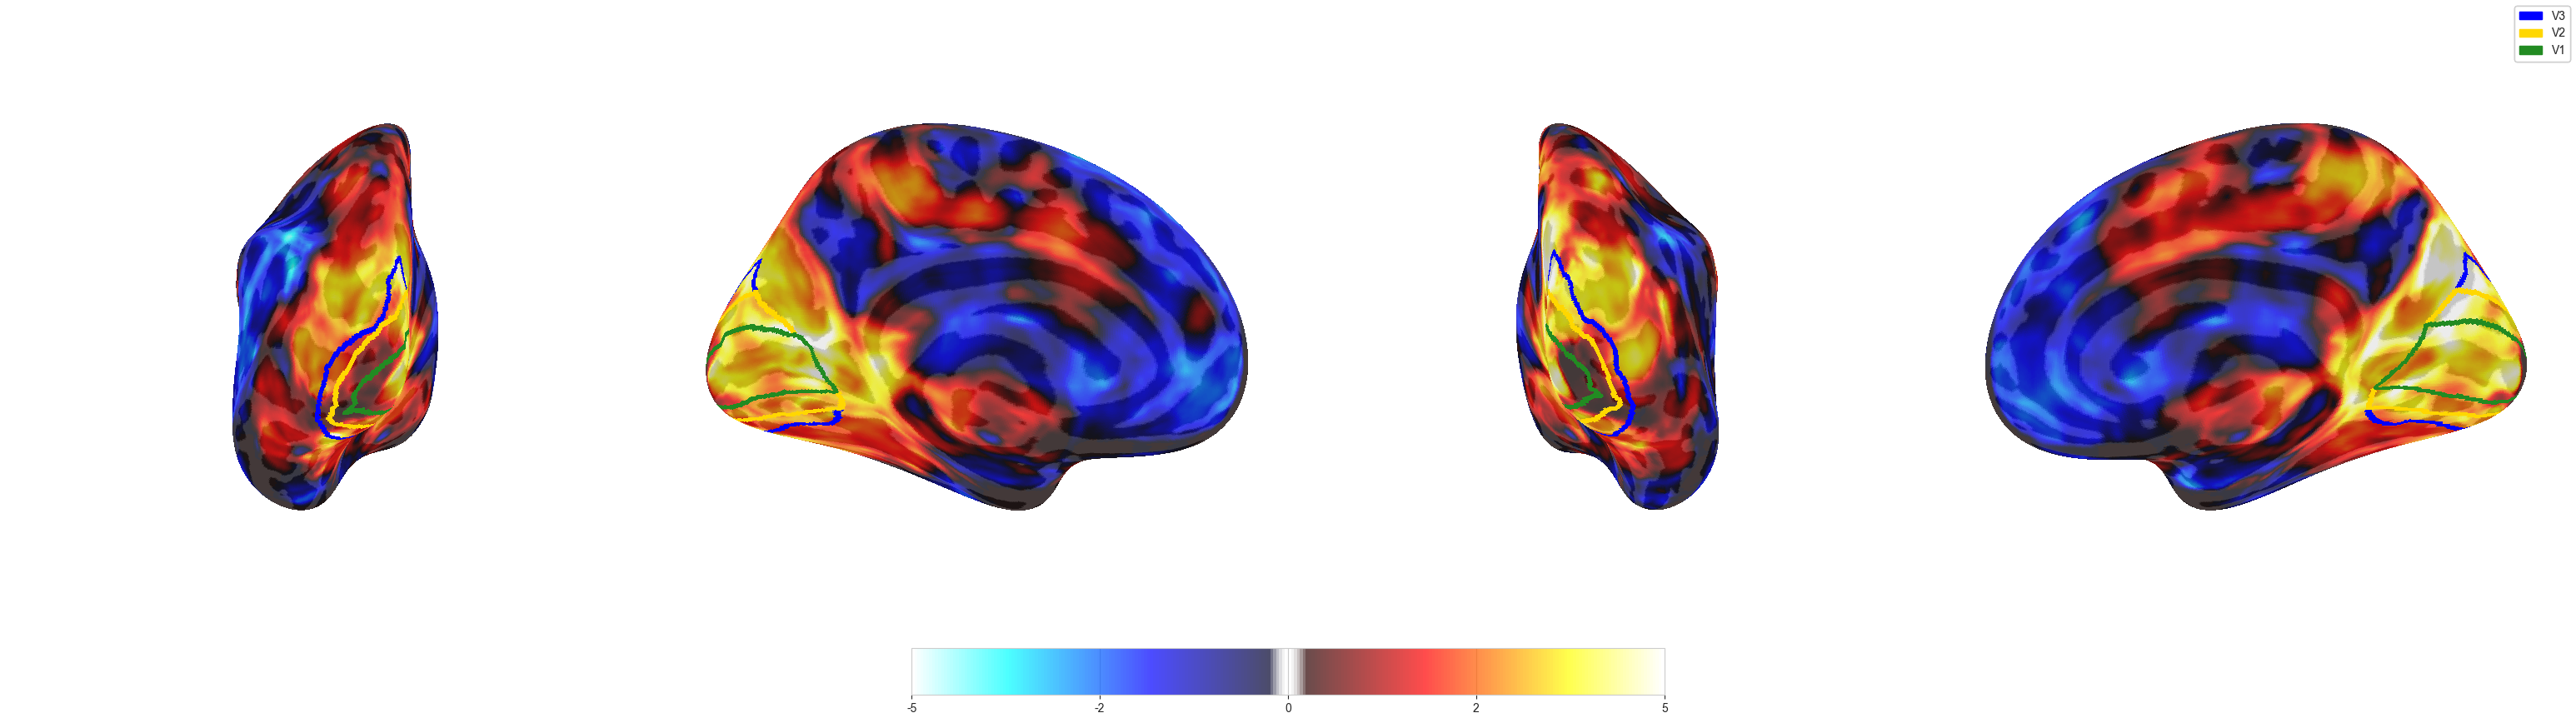

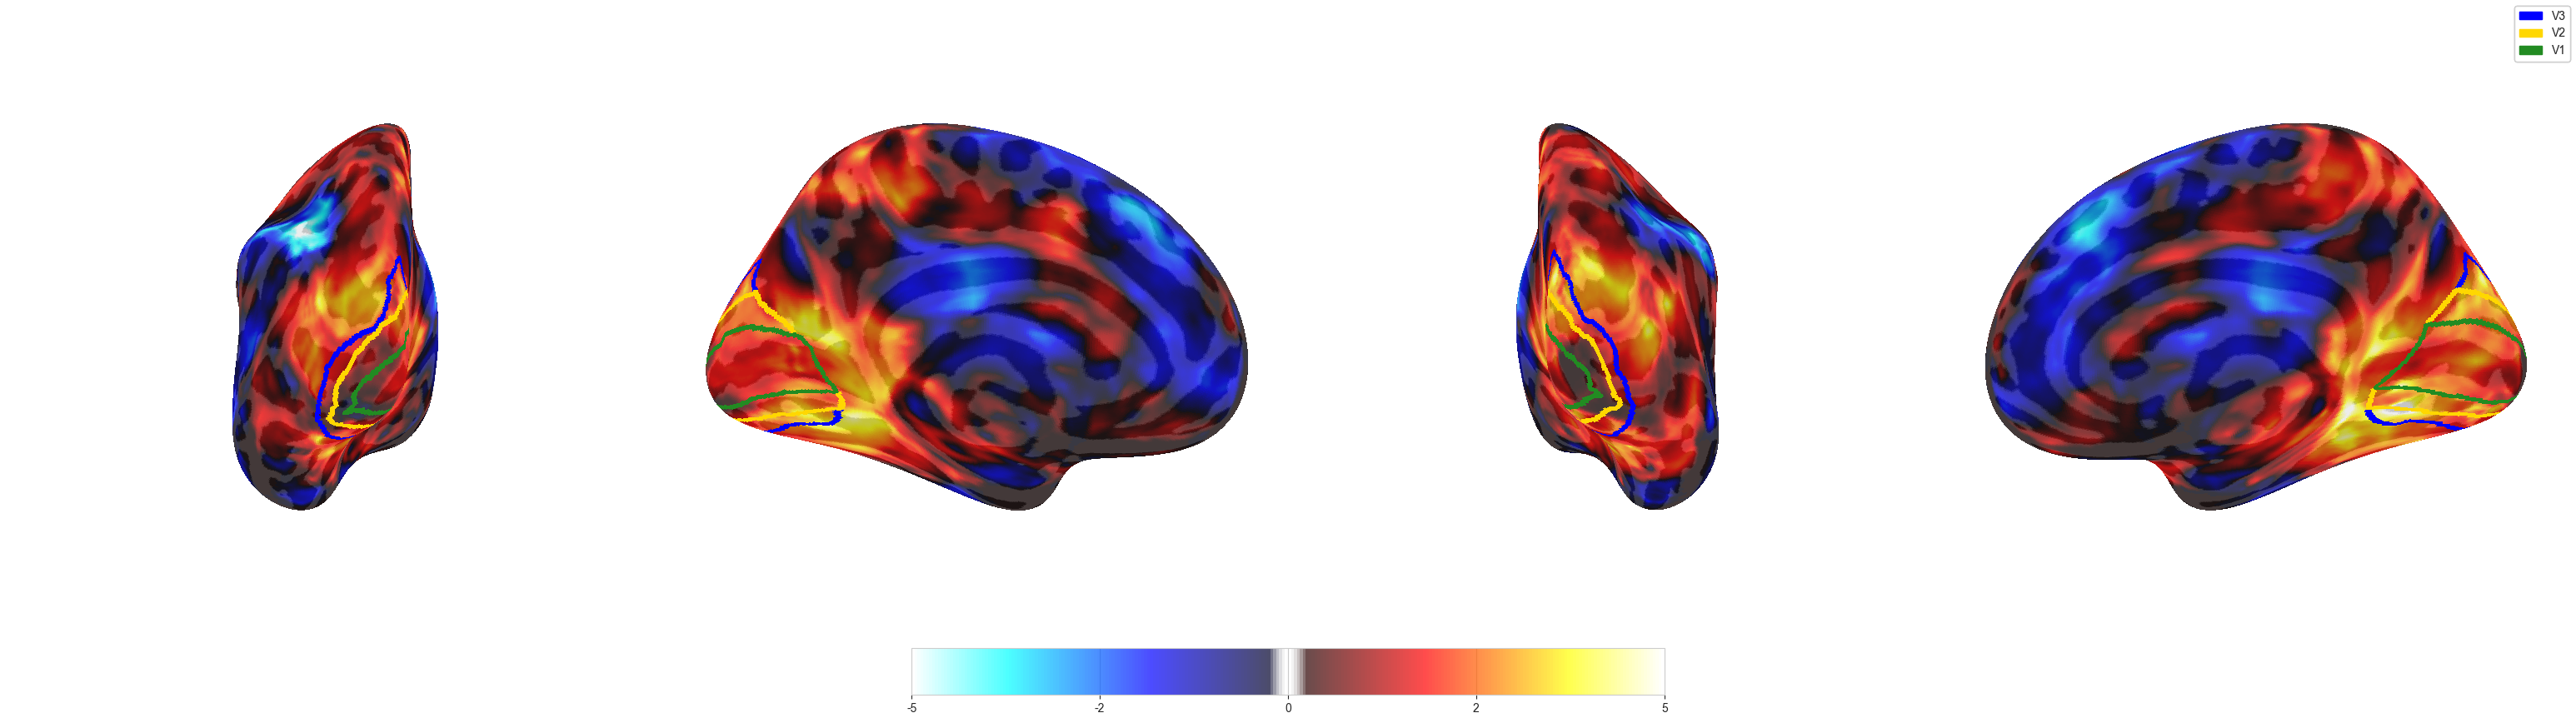

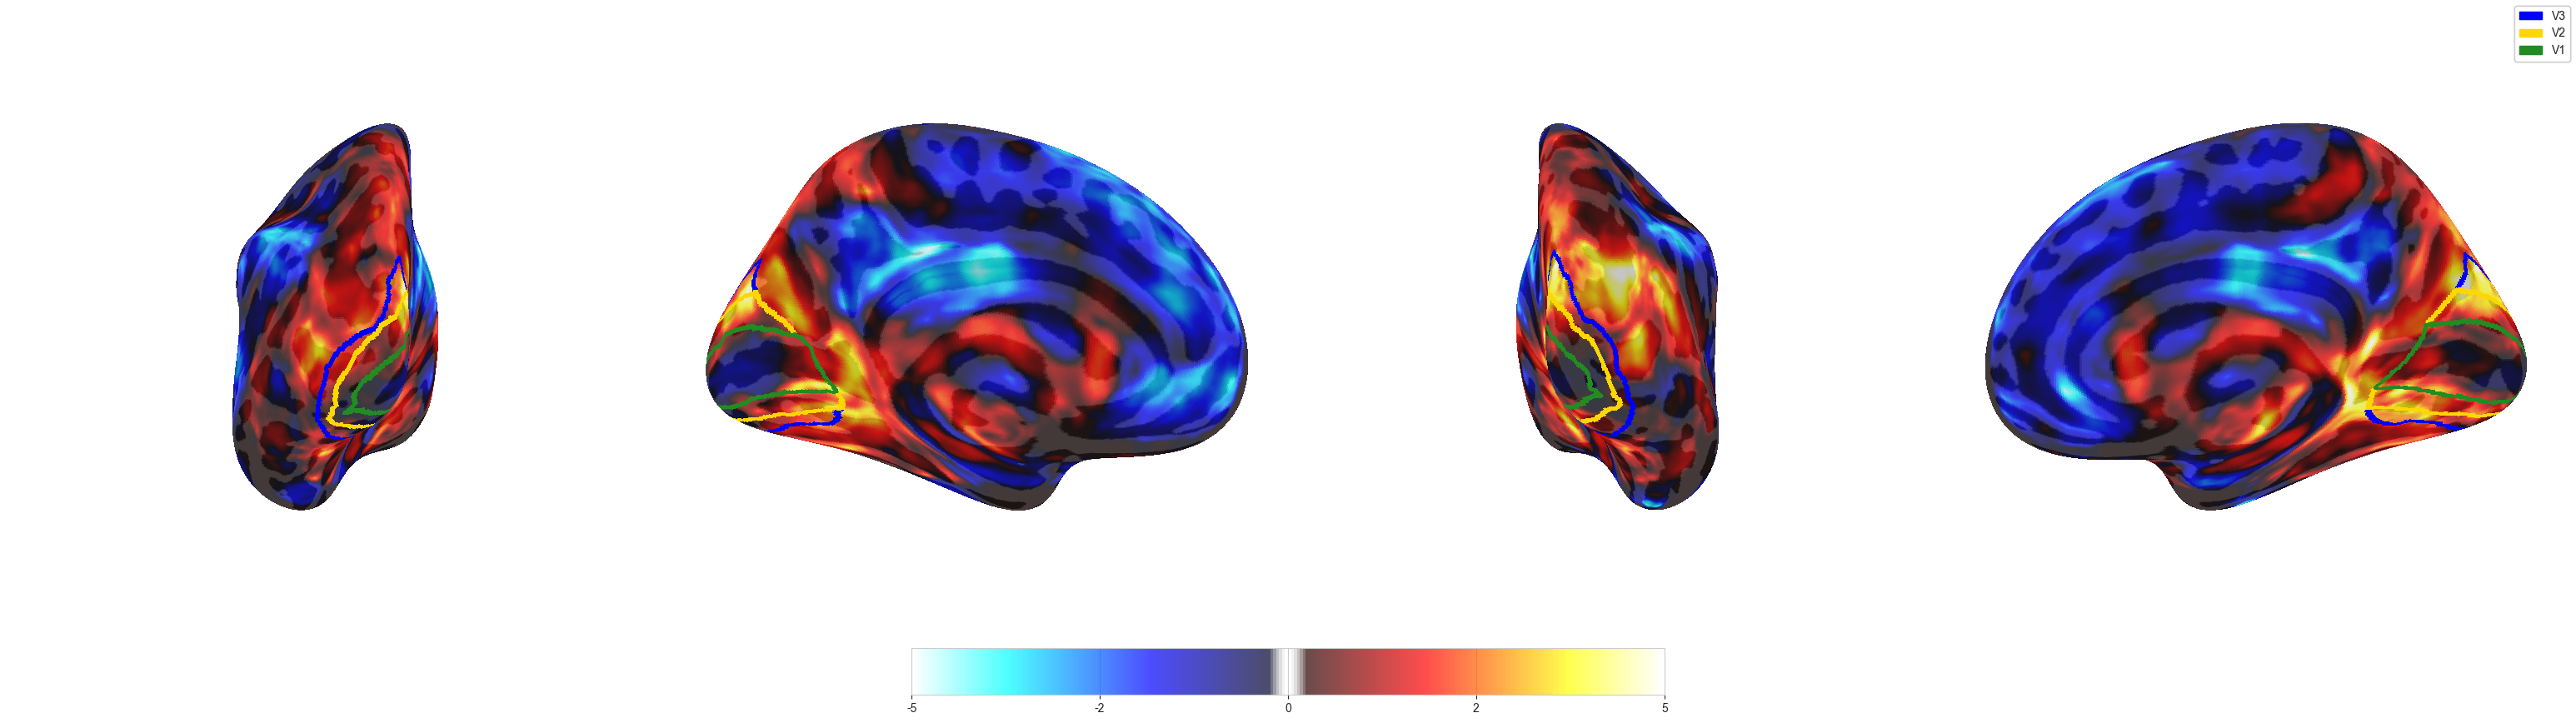

In [26]:
# Now for the split states 

from mreyemove.analysis.glm.atlas import fetch_atlas
from nilearn.datasets import load_fsaverage
atlas = fetch_atlas("benson")

from mreyemove.plotting.glm_surface import plot_img_on_surf_with_contour
from nilearn import image, datasets
from mreyemove.plotting.glm import custom_cmap
mrio = SleepMRIO(
    bids_root="/Users/zach/2025_RA/matthias/bids_sleepmreye",
    tr=2.1,
    task="sleep",
    load_signal=True,
    desc_add="clean",
    ignore_boundary_trs=0,
    load_eog=False,
    data_dir="/Users/zach/2025_RA/matthias/bids_sleepmreye/derivatives/fmriprep"
)
config = GLMConfig.from_yaml("/Users/zach/2025_RA/matthias/eyemove_and_sleep/SleepMReye/sleepmreye/designs/original.yml")
desc_add = construct_desc(dataset=mrio, config=config)
desc_add = f"{desc_add}-{config.second_level.method}"


surf_mesh = "fsaverage7"
fsaverage7 = datasets.fetch_surf_fsaverage(mesh=surf_mesh)
    
roi_surf = {}
proj_kwargs = dict(interpolation="linear", radius=3.0, kind="line", n_samples=10)

contrasts = ("mreyemove_W", "mreyemove_1", "mreyemove_2")
contrast_map = {contrast: mrio.load_FLAME_result(contrast=contrast, desc_add=desc_add)[0].t_stat for contrast in contrasts}
panels = [
        ("left", "posterior"),
        ("left", "medial"),
        ("right", "posterior"),
        ("right", "medial"),
    ]
for contrast in contrasts:
    t_masked = contrast_map[contrast]
    
    plot_img_on_surf_with_contour(
        surf_mesh=surf_mesh,
        stat_map=t_masked,
        roi_map=atlas.maps.data.parts,
        levels=[3,2,1],
        labels=["V3", "V2", "V1"],
        contour_width=2,
        colors=["blue", "gold", "forestgreen"],
        vmin=-5, vmax=5,
        cmap=custom_cmap(),
        inflate=True,
        bg_on_data=True,
        panels=panels,
        legend=True,
    )
# plotting.view_img(atlas.maps)

[fetch_surf_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage


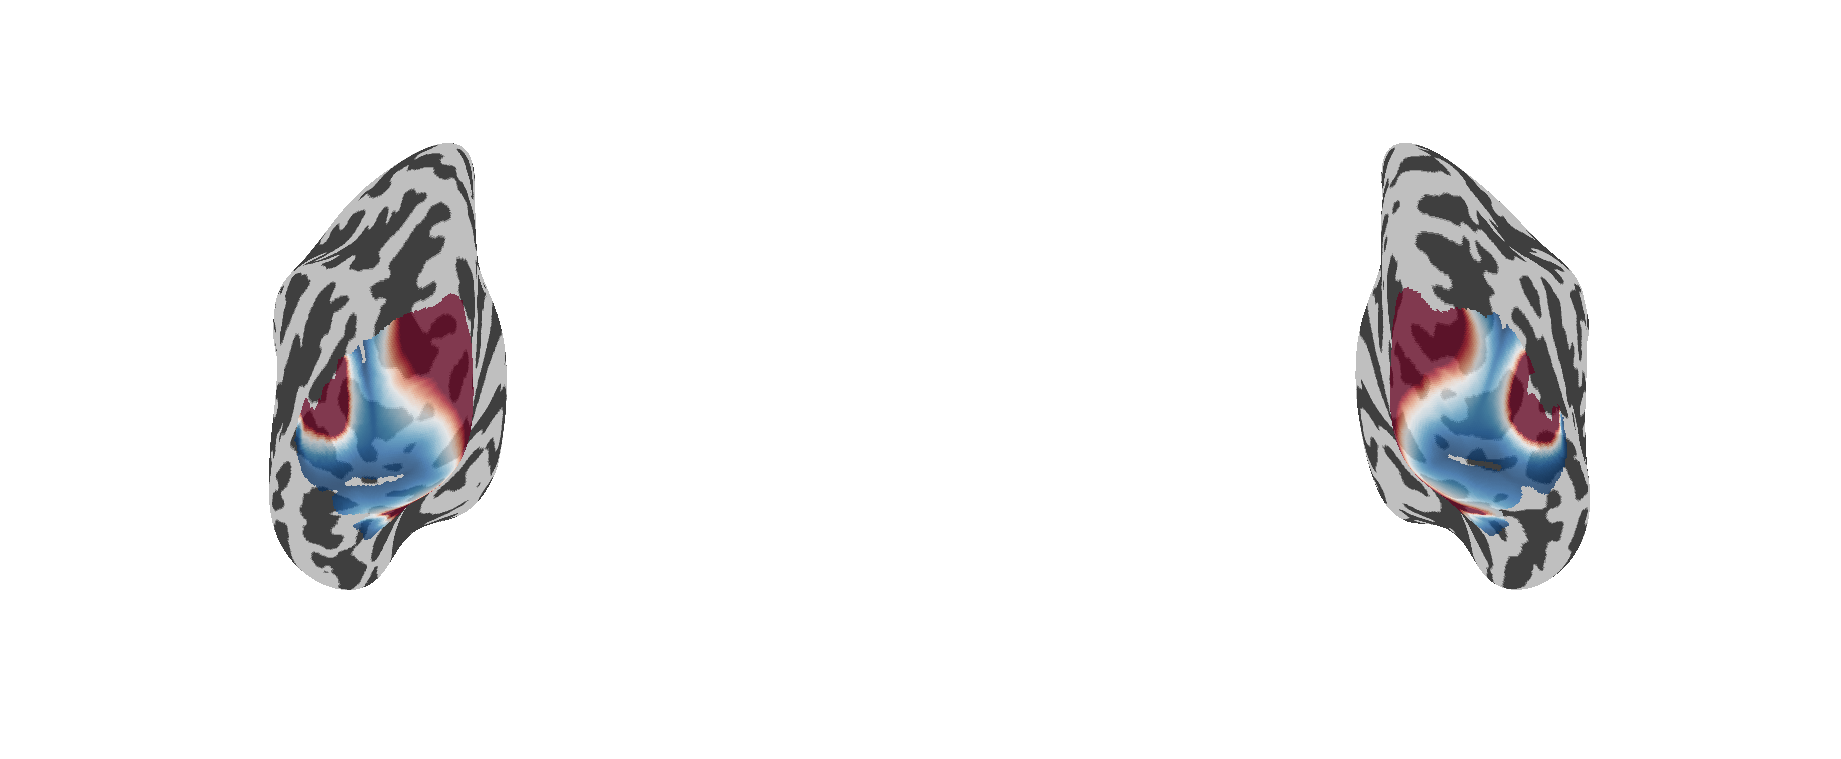

In [24]:
# Now I want to do the same for eccentricity maps
# FIrst I want to see what the eccentricity map looks like

from matplotlib.gridspec import GridSpecFromSubplotSpec
from nilearn.plotting.surface._matplotlib_backend import _colorbar_from_array, _get_ticks
import nibabel as nib 
from pathlib import Path
from nilearn.surface import load_surf_data, SurfaceImage
from nilearn import datasets
import neuropythy as ny
import numpy as np 
from matplotlib import pyplot as plt 

fsaverage7 = datasets.fetch_surf_fsaverage(mesh="fsaverage7")

cache_dir = Path(ny.library_path()) / "data/fsaverage/surf/"
lh_benson_path = cache_dir / "lh.benson14_eccen.v4_0.mgz"
rh_benson_path = cache_dir / "rh.benson14_eccen.v4_0.mgz"
lh_benson = nib.load(lh_benson_path)
rh_benson = nib.load(rh_benson_path)

lh_data = lh_benson.get_fdata().squeeze()
lh_data[lh_data < 0.1] = np.nan

rh_data = rh_benson.get_fdata().squeeze()
rh_data[rh_data < 0.1] = np.nan

# fsaverage = load_fsaverage("fsaverage7")
mesh = {
    "left": fsaverage7["infl_left"],
    "right": fsaverage7["infl_right"],
}
labels_img = SurfaceImage(
    mesh=mesh,
    data={
        "left": lh_data,
        "right": rh_data,
    },
)

bg_data = {}
for hemi in ("left", "right"):
    curv_map = load_surf_data(fsaverage7[f"curv_{hemi}"])
    curv_sign_map = (np.sign(curv_map) + 1) / 4 + 0.25
    bg_map = curv_sign_map
    bg_data[hemi] = bg_map

bg_map = SurfaceImage(
    mesh=mesh,
    data={
        "left": bg_data["left"],
        "right": bg_data["right"],
    },
)    


cbar_h = 0.25
title_h = 0.25
w, h = plt.figaspect((1 + cbar_h + title_h) / 4)
f, axs = plt.subplots(1, 2, subplot_kw={"projection": "3d"}, figsize=(w * 2, h * 2), constrained_layout=False)
axs = axs.ravel()
from nilearn import plotting, image
from itertools import product 

vmin = 0.1
vmax = 5
colorbar = False
for i, (hemi, view) in enumerate(product(["left", "right"],["posterior"])):
    if i == 3:
        colorbar = True
    
    plotting.plot_surf_stat_map(stat_map=labels_img, bg_on_data=True, darkness=None, vmin=vmin, vmax=vmax, hemi=hemi, view=view, bg_map=bg_map, axes=axs[i], colorbar=colorbar)
    

In [1]:
# Now let's create an atlas of foveal (<= 2 dva) and peripheral (> 2 dva) vision 
from mreyemove.analysis.glm.atlas import Atlas

import nibabel as nib 
from pathlib import Path
from nilearn.surface import load_surf_data, SurfaceImage
from nilearn import datasets
import neuropythy as ny
import numpy as np 
from matplotlib import pyplot as plt 
import pandas as pd 

fsaverage7 = datasets.fetch_surf_fsaverage(mesh="fsaverage7")

cache_dir = Path(ny.library_path()) / "data/fsaverage/surf/"
lh_eccen_path = cache_dir / "lh.benson14_eccen.v4_0.mgz"
rh_eccen_path = cache_dir / "rh.benson14_eccen.v4_0.mgz"
lh_eccen = nib.load(lh_eccen_path).get_fdata().squeeze()
rh_eccen = nib.load(rh_eccen_path).get_fdata().squeeze()

lh_varea_path = cache_dir / "lh.benson14_varea.v4_0.mgz"
rh_varea_path = cache_dir / "rh.benson14_varea.v4_0.mgz"
lh_varea = nib.load(lh_varea_path).get_fdata().squeeze()
rh_varea = nib.load(rh_varea_path).get_fdata().squeeze()

def eccen_to_atlas(ecc, varea, fovea_dva=2):
    out = np.zeros_like(ecc)    
    # Make sure we are only looking at visual cortex, otherwise everywhere outside it will be 1
    out[(varea > 0) & (ecc <= fovea_dva)] = 1   
    out[ecc >  fovea_dva] = 2   
    return out

lh_data = eccen_to_atlas(lh_eccen, lh_varea)
rh_data = eccen_to_atlas(rh_eccen, rh_varea)
# fsaverage = load_fsaverage("fsaverage7")
mesh = {
    "left": fsaverage7["infl_left"],
    "right": fsaverage7["infl_right"],
}
labels_img = SurfaceImage(
    mesh=mesh,
    data={
        "left": lh_data,
        "right": rh_data,
    },
)

labels = ["Background", "fovea", "periphery"]
idx = [0,1,2]
lut = pd.DataFrame({
    "index": idx,
    "name":labels,
})
eccentricity_atlas = Atlas(
    maps=labels_img,
    labels=labels,
    lut=lut,
)


[fetch_surf_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage


In [11]:
eccentricity_atlas.lut

,index,labels
0,0,Background
1,1,fovea
2,2,periphery


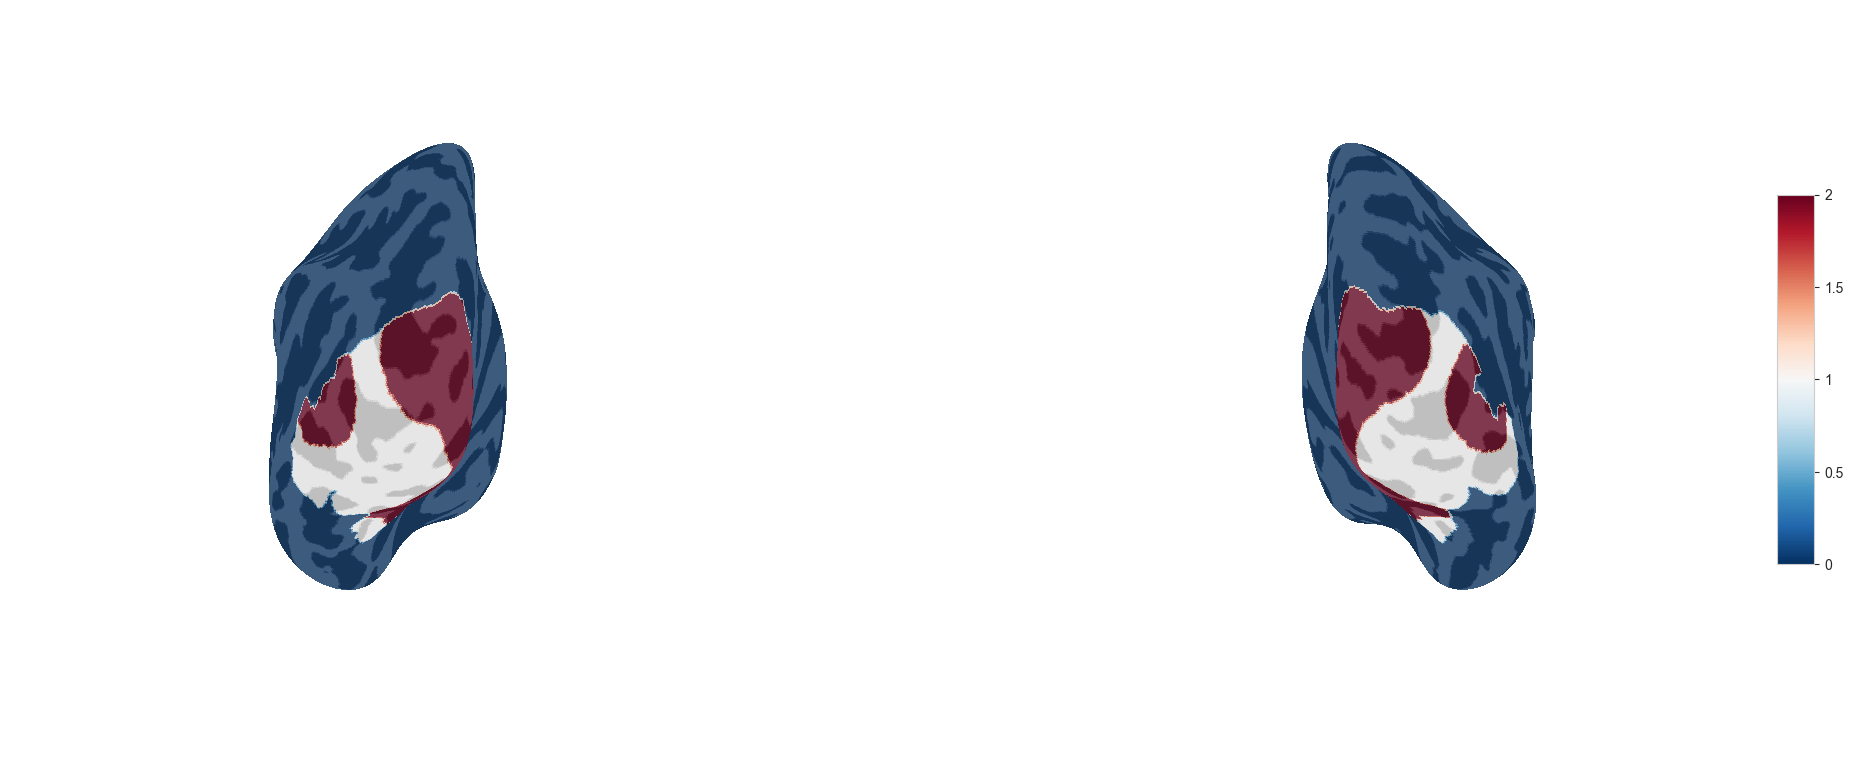

In [17]:
# And then the plotting to confirm it looks good  

mesh = {
    "left": fsaverage7["infl_left"],
    "right": fsaverage7["infl_right"],
}
labels_img = SurfaceImage(
    mesh=mesh,
    data={
        "left": lh_data,
        "right": rh_data,
    },
)

bg_data = {}
for hemi in ("left", "right"):
    curv_map = load_surf_data(fsaverage7[f"curv_{hemi}"])
    curv_sign_map = (np.sign(curv_map) + 1) / 4 + 0.25
    bg_map = curv_sign_map
    bg_data[hemi] = bg_map

bg_map = SurfaceImage(
    mesh=mesh,
    data={
        "left": bg_data["left"],
        "right": bg_data["right"],
    },
)    

plots = 2
cbar_h = 0.25
title_h = 0.25
w, h = plt.figaspect((1 + cbar_h + title_h) / 4)
f, axs = plt.subplots(1, plots, subplot_kw={"projection": "3d"}, figsize=(w * 2, h * 2), constrained_layout=False)
axs = axs.ravel()
from nilearn import plotting, image
from itertools import product 

vmin = 0
vmax = 2
colorbar = False
for i, (hemi, view) in enumerate(product(["left", "right"],["posterior"])):
    if i == plots-1:
        colorbar = True
    
    plotting.plot_surf_stat_map(stat_map=labels_img, bg_on_data=True, darkness=None, vmin=vmin, vmax=vmax, hemi=hemi, view=view, bg_map=bg_map, axes=axs[i], colorbar=colorbar)
    

[fetch_surf_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
[check_mesh_is_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
[check_mesh_is_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage


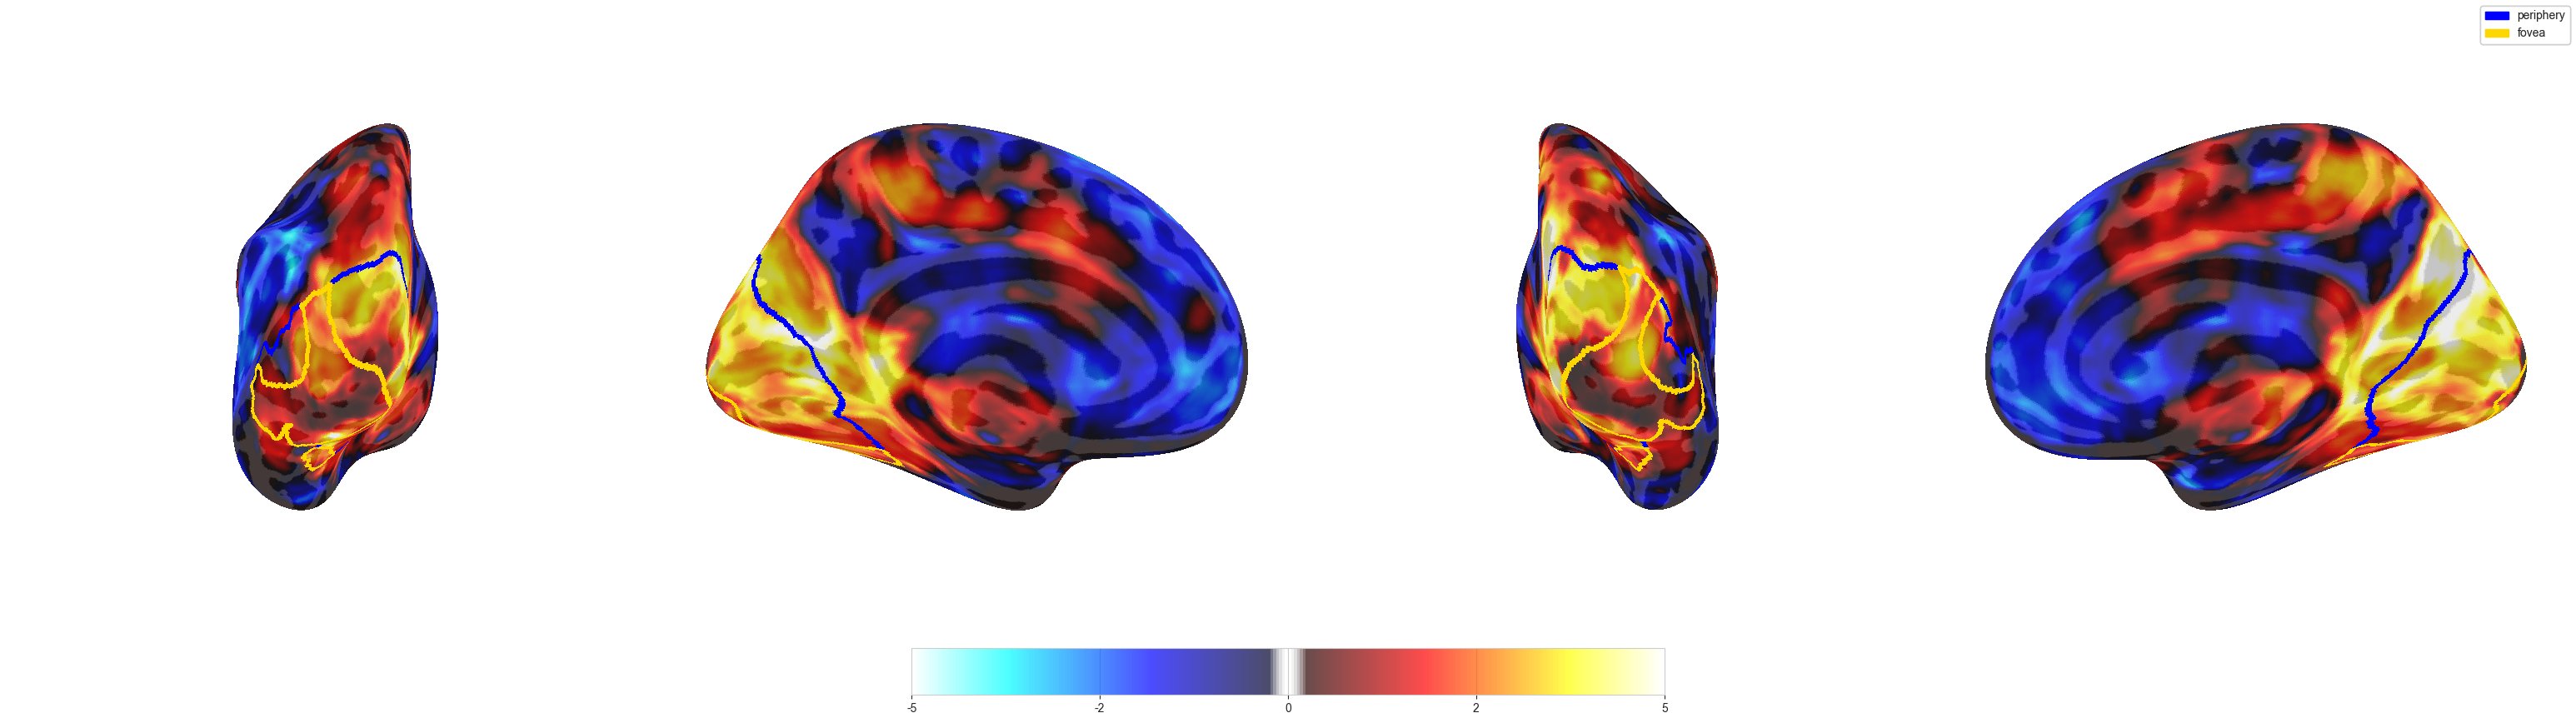

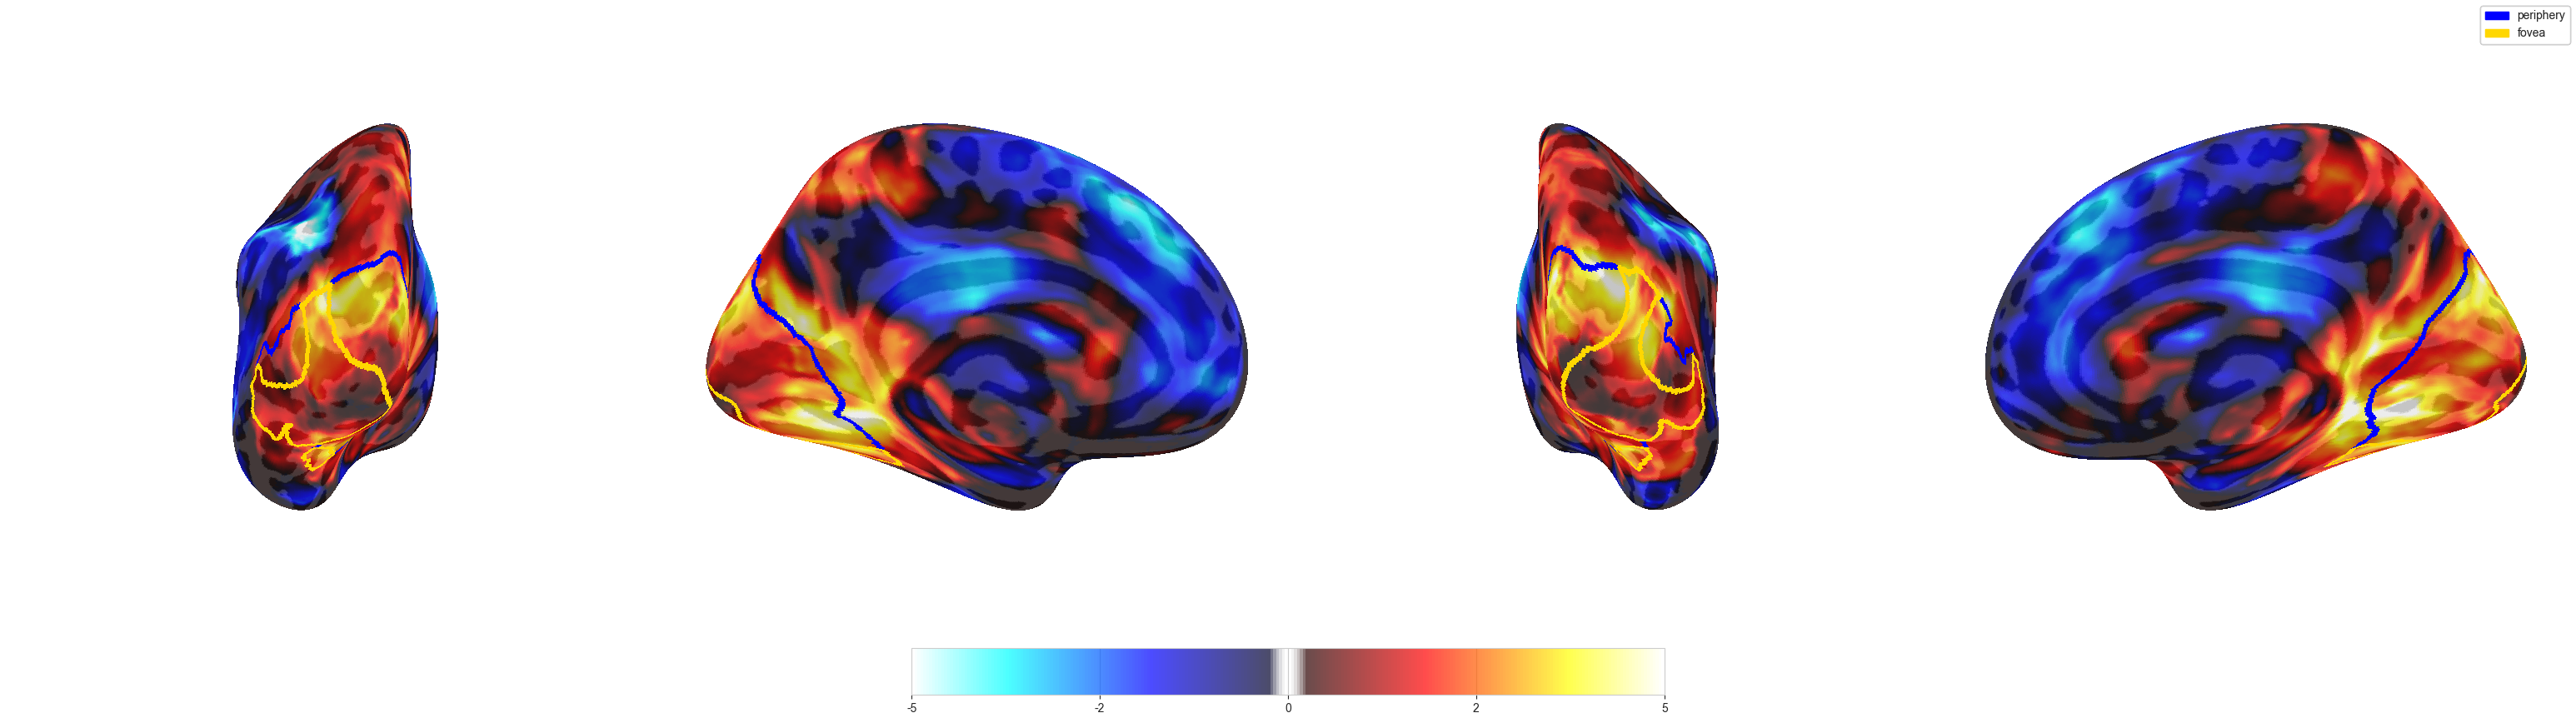

In [24]:
# Nice. Now we know what the atlas looks like, lets overlay it on group level maps 


from mreyemove.analysis.glm.atlas import fetch_atlas
from nilearn.datasets import load_fsaverage

from mreyemove.plotting.glm_surface import plot_img_on_surf_with_contour
from nilearn import image, datasets
from mreyemove.plotting.glm import custom_cmap

surf_mesh = "fsaverage7"
fsaverage7 = datasets.fetch_surf_fsaverage(mesh=surf_mesh)
    
roi_surf = {}
proj_kwargs = dict(interpolation="linear", radius=3.0, kind="line", n_samples=10)

contrasts = ("mreyemove_W", "mreyemove_S")
contrast_map = {contrast: mrio.load_FLAME_result(contrast=contrast, desc_add=desc_add)[0].t_stat for contrast in contrasts}
panels = [
        ("left", "posterior"),
        ("left", "medial"),
        ("right", "posterior"),
        ("right", "medial"),
    ]
for contrast in contrasts:
    t_masked = contrast_map[contrast]
    
    plot_img_on_surf_with_contour(
        surf_mesh=surf_mesh,
        stat_map=t_masked,
        roi_map=eccentricity_atlas.maps.data.parts,
        levels=[2,1],
        labels=["periphery", "fovea"],
        contour_width=2,
        colors=["blue", "gold"],
        vmin=-5, vmax=5,
        cmap=custom_cmap(),
        inflate=True,
        bg_on_data=True,
        panels=panels,
        legend=True,
    )
# plotting.view_img(atlas.maps)

[load_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
[fetch_surf_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
[check_mesh_is_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
[check_mesh_is_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
[check_mesh_is_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage


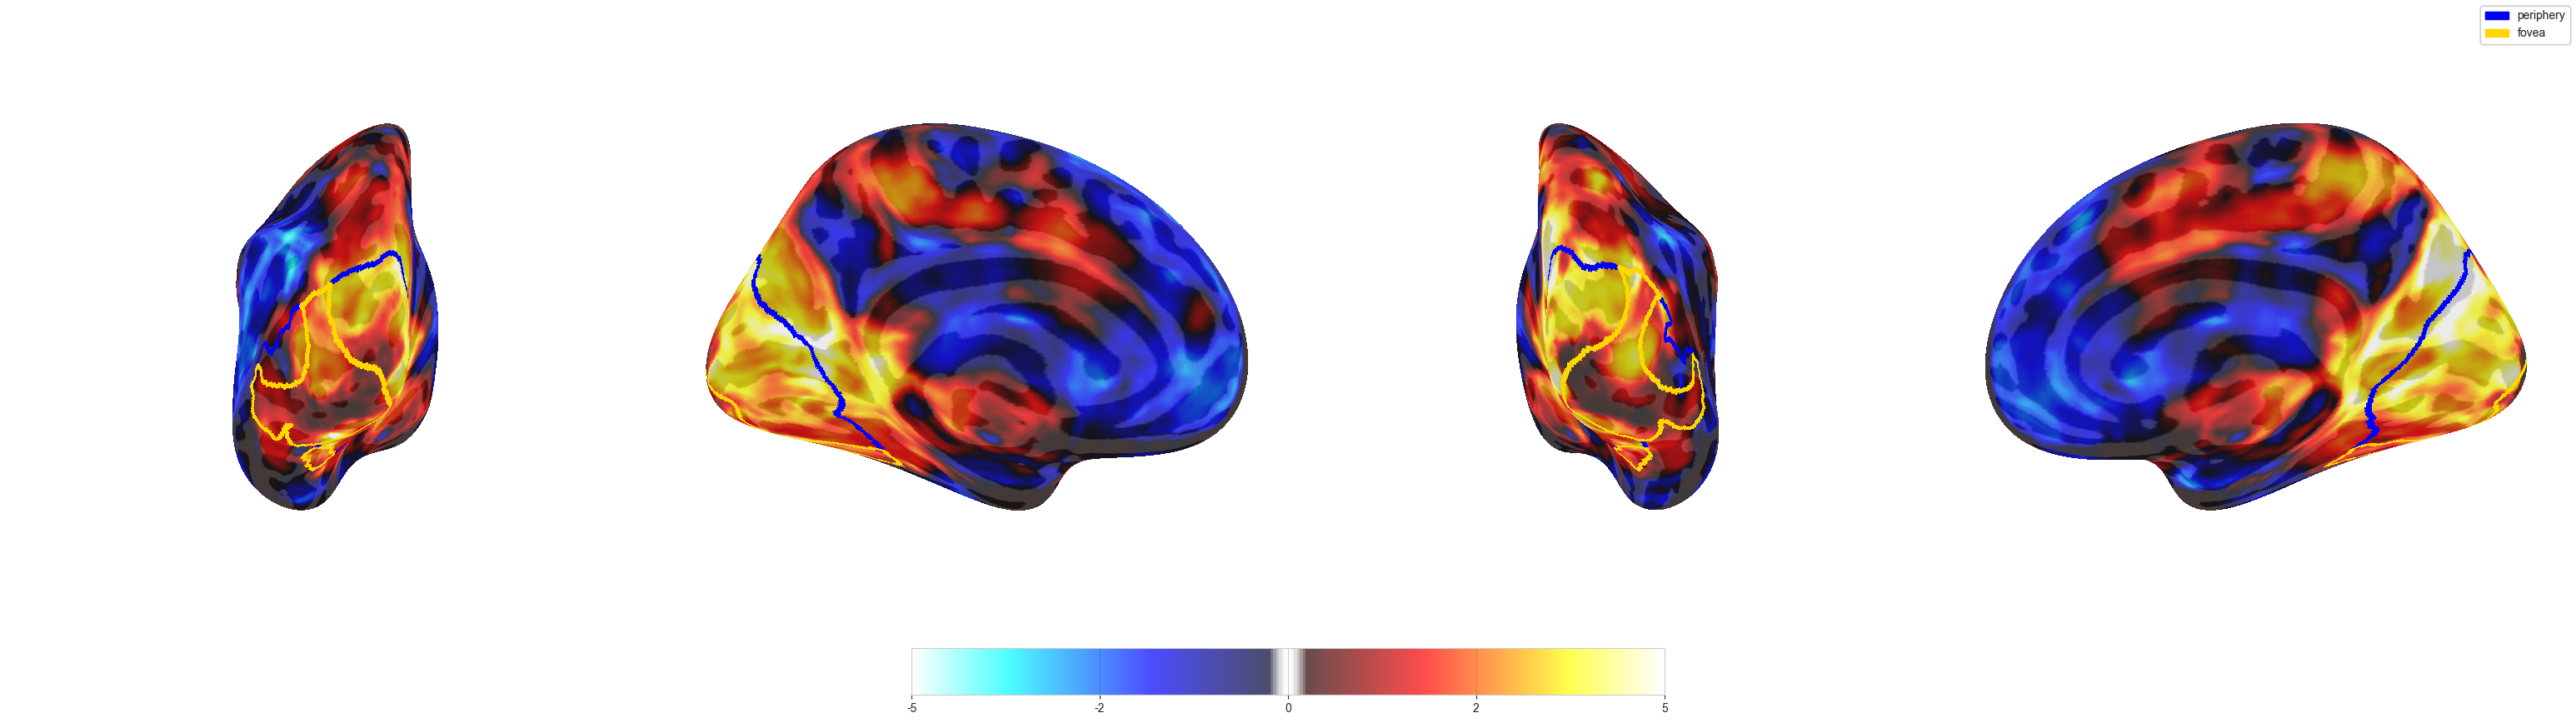

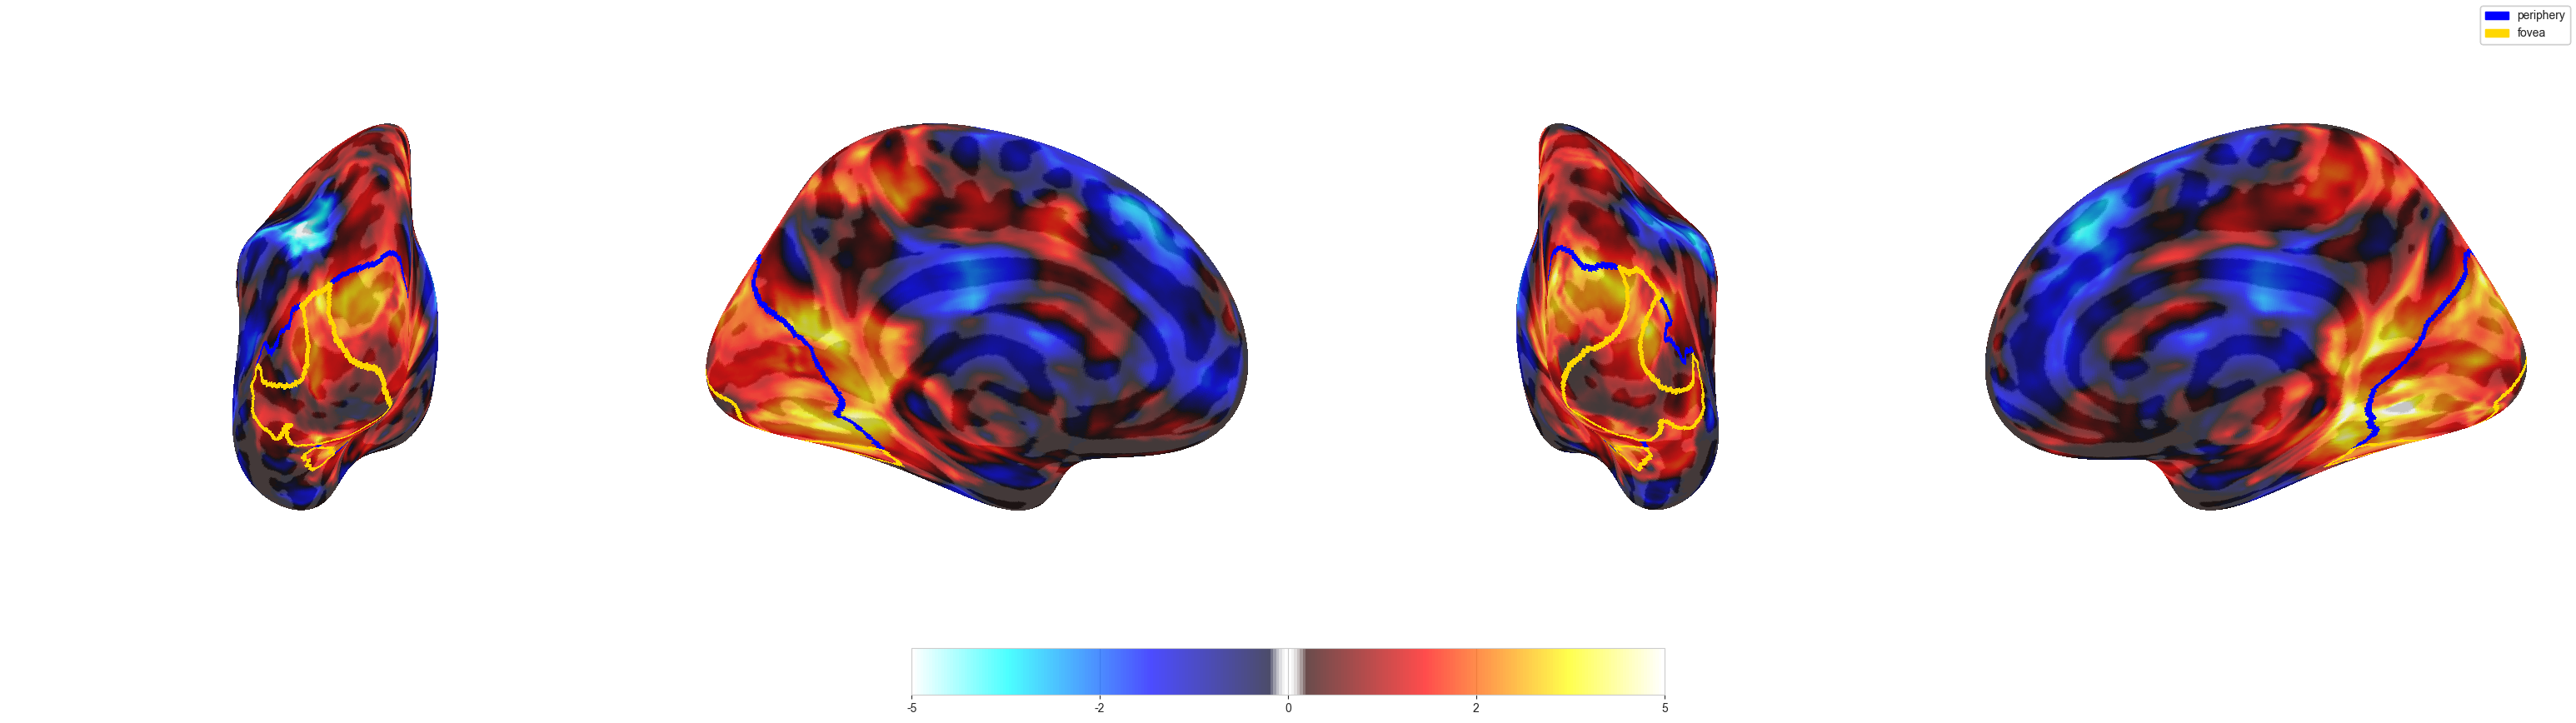

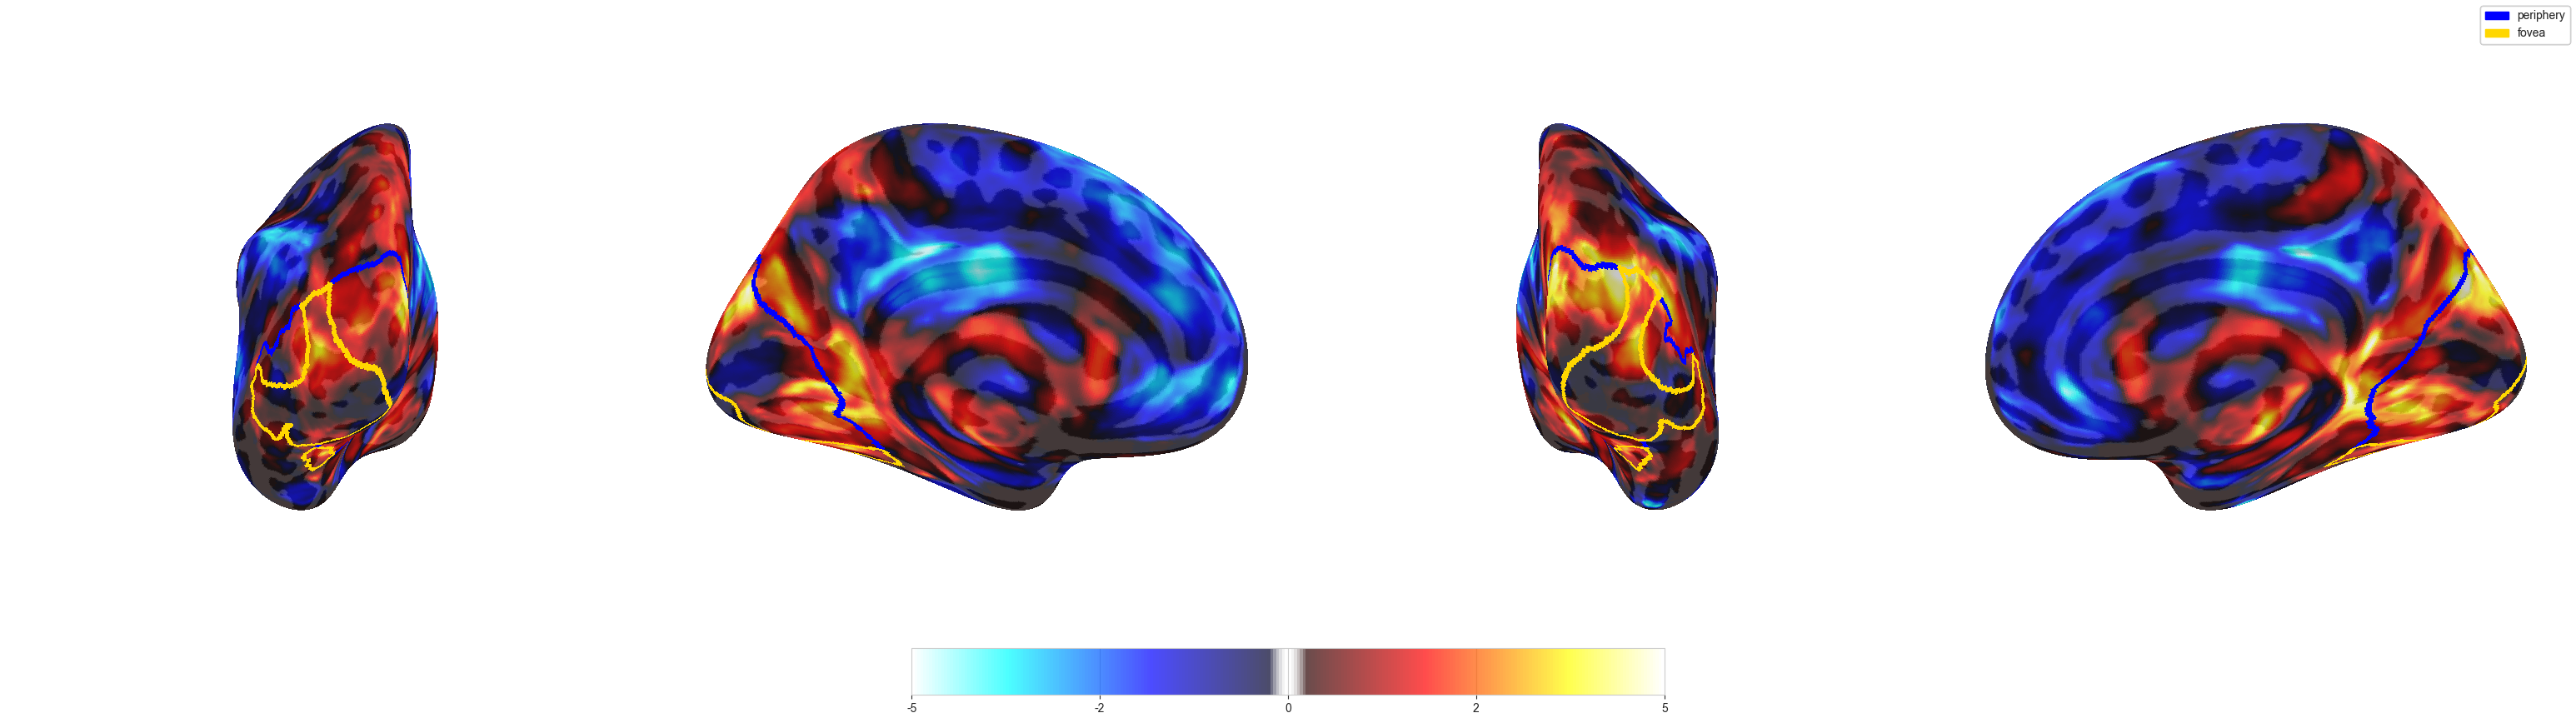

In [27]:
# Now for the split states 

from mreyemove.analysis.glm.atlas import fetch_atlas
from nilearn.datasets import load_fsaverage
atlas = fetch_atlas("benson")

from mreyemove.plotting.glm_surface import plot_img_on_surf_with_contour
from nilearn import image, datasets
from mreyemove.plotting.glm import custom_cmap
mrio = SleepMRIO(
    bids_root="/Users/zach/2025_RA/matthias/bids_sleepmreye",
    tr=2.1,
    task="sleep",
    load_signal=True,
    desc_add="clean",
    ignore_boundary_trs=0,
    load_eog=False,
    data_dir="/Users/zach/2025_RA/matthias/bids_sleepmreye/derivatives/fmriprep"
)
config = GLMConfig.from_yaml("/Users/zach/2025_RA/matthias/eyemove_and_sleep/SleepMReye/sleepmreye/designs/original.yml")
desc_add = construct_desc(dataset=mrio, config=config)
desc_add = f"{desc_add}-{config.second_level.method}"


surf_mesh = "fsaverage7"
fsaverage7 = datasets.fetch_surf_fsaverage(mesh=surf_mesh)
    
roi_surf = {}
proj_kwargs = dict(interpolation="linear", radius=3.0, kind="line", n_samples=10)

contrasts = ("mreyemove_W", "mreyemove_1", "mreyemove_2")
contrast_map = {contrast: mrio.load_FLAME_result(contrast=contrast, desc_add=desc_add)[0].t_stat for contrast in contrasts}
panels = [
        ("left", "posterior"),
        ("left", "medial"),
        ("right", "posterior"),
        ("right", "medial"),
    ]
for contrast in contrasts:
    t_masked = contrast_map[contrast]
    
    plot_img_on_surf_with_contour(
        surf_mesh=surf_mesh,
        stat_map=t_masked,
        roi_map=eccentricity_atlas.maps.data.parts,
        levels=[2,1],
        labels=["periphery", "fovea"],
        contour_width=2,
        colors=["blue", "gold"],
        vmin=-5, vmax=5,
        cmap=custom_cmap(),
        inflate=True,
        bg_on_data=True,
        panels=panels,
        legend=True,
    )
# plotting.view_img(atlas.maps)

In [39]:
roi_data_path = out_dir / f"roi_run_data.tsv"
data = pd.read_csv(roi_data_path, sep="\t")
data[(data.contrast == "mreyemove_W") & (data.label == "V1")]["t"].mean()

1.0770253795181515

In [55]:
from nilearn.maskers import NiftiLabelsMasker, SurfaceLabelsMasker

result_data, _ = mrio.load_FLAME_result(contrast="mreyemove_W", desc_add=desc_add)
masker = SurfaceLabelsMasker(
            labels_img=atlas.maps,
            lut=atlas.lut,
            verbose=0,
            strategy="mean",
            memory="nilearn_cache",
            standardize=False,
        )
fsaverage = load_fsaverage("fsaverage7")
surface_t_stat = SurfaceImage.from_volume(
                mesh=fsaverage["pial"],
                volume_img=result_data.t_stat,
            )
masker.fit(surface_t_stat)
t_vals = masker.transform(surface_t_stat).ravel()

t_df = atlas.lut.copy()
t_df["t_vals"] = np.zeros(13)
t_df.loc[1:, "t_vals"] = t_vals
t_df

[load_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage


AttributeError: 'numpy.ndarray' object has no attribute 'values'

In [60]:

t_df = atlas.lut.copy()
t_df["t_vals"] = np.zeros(13)
t_df.loc[1:, "t_vals"] = t_vals
t_df

,index,name,t_vals
0,0,Background,0.000000
1,1,V1,3.097137
2,2,V2,2.576967
3,3,V3,2.746510
4,4,hV4,1.738670
5,5,VO1,2.303014
6,6,VO2,1.833128
7,7,LO1,2.307506
8,8,LO2,0.648809
9,9,TO1,0.916531


In [68]:
from nilearn.maskers import NiftiLabelsMasker, SurfaceLabelsMasker

result_data, _ = mrio.load_FLAME_result(contrast="mreyemove_S", desc_add=desc_add)
masker = SurfaceLabelsMasker(
            labels_img=atlas.maps,
            lut=atlas.lut,
            verbose=0,
            strategy="mean",
            memory="nilearn_cache",
            standardize=False,
        )
fsaverage = load_fsaverage("fsaverage7")
surface_t_stat = SurfaceImage.from_volume(
                mesh=fsaverage["pial"],
                volume_img=result_data.t_stat,
            )
masker.fit(surface_t_stat)
t_vals = masker.transform(surface_t_stat).ravel()

t_df = atlas.lut.copy()
t_df["t_vals"] = np.zeros(13)
t_df.loc[1:, "t_vals"] = t_vals
t_df

[load_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage


,index,name,t_vals
0,0,Background,0.000000
1,1,V1,1.747582
2,2,V2,2.203596
3,3,V3,2.583243
4,4,hV4,1.873319
5,5,VO1,2.931719
6,6,VO2,3.068023
7,7,LO1,2.353309
8,8,LO2,0.983081
9,9,TO1,1.150222


In [65]:
import pandas as pd 
pd.read_csv("/Users/zach/2025_RA/matthias/bids_sleepmreye/derivatives/mreyemove/group/func/glm_brain/roi_lme/desc-clean-original-sleep-flame/roi_test_results_copes.tsv", sep="\t").sort_values(by=["contrast", "label"])


,contrast,atlas,label,t_stat,p_val,n,p_fdr
0,mreyemove,benson,V1,1.868867,0.007700,31,0.007700
1,mreyemove,benson,V2,2.476130,0.000300,31,0.000900
2,mreyemove,benson,V3,2.638746,0.001900,31,0.002850
3,mreyemove_S,benson,V1,1.648085,0.089996,31,0.091195
4,mreyemove_S,benson,V2,1.755504,0.091195,31,0.091195
5,mreyemove_S,benson,V3,1.979291,0.047648,31,0.091195
6,mreyemove_W,benson,V1,1.798341,0.056097,31,0.056097
7,mreyemove_W,benson,V2,2.141751,0.019499,31,0.029249
8,mreyemove_W,benson,V3,2.349926,0.018049,31,0.029249
9,mreyemove_W-mreyemove_S,benson,V1,0.287737,0.777211,31,0.897605


In [24]:
import pandas as pd 
pd.read_csv("/Users/zach/2025_RA/matthias/bids_sleepmreye/derivatives/mreyemove/group/func/glm_brain/roi_lme/desc-clean-original-sleep-flame/roi_test_results_tscores.tsv", sep="\t").sort_values(by=["contrast", "label"])


,contrast,atlas,label,t_stat,p_val,n,p_fdr
0,mreyemove,benson,V1,3.682045,0.000350,31,0.000350
1,mreyemove,benson,V2,4.171746,0.000150,31,0.000225
2,mreyemove,benson,V3,4.202076,0.000150,31,0.000225
3,mreyemove_S,benson,V1,2.662030,0.010799,31,0.010799
4,mreyemove_S,benson,V2,3.843405,0.000450,31,0.000675
5,mreyemove_S,benson,V3,4.141012,0.000250,31,0.000675
6,mreyemove_W,benson,V1,3.721171,0.000250,31,0.000250
7,mreyemove_W,benson,V2,3.751357,0.000100,31,0.000150
8,mreyemove_W,benson,V3,3.688327,0.000050,31,0.000150
9,mreyemove_W-mreyemove_S,benson,V1,0.135755,0.892805,31,0.892805


In [81]:
from pathlib import Path
import neuropythy as ny
cache_dir = Path(ny.library_path()) / "data/fsaverage/surf/"
cache_dir

PosixPath('/Users/zach/.virtualenvs/testmreyemove/lib/python3.11/site-packages/neuropythy/lib/data/fsaverage/surf')

In [83]:
import pandas as pd 
df = pd.read_csv("/Users/zach/2025_RA/matthias/bids_sleepmreye/derivatives/mreyemove/group/func/glm_brain/roi_lme/desc-clean-original-sleep-flame/benson_roi_test_results_copes.tsv", sep="\t").sort_values(by=["contrast", "label"])
df[df["contrast"] != "mreyemove"]

,contrast,atlas,label,t_stat,p_val,n,p_fdr
12,mreyemove_S,benson,LO1,0.478674,0.701765,31,0.765562
13,mreyemove_S,benson,LO2,0.113348,0.921854,31,0.921854
14,mreyemove_S,benson,TO1,0.885552,0.392730,31,0.523640
15,mreyemove_S,benson,TO2,2.163611,0.034248,31,0.136993
16,mreyemove_S,benson,V1,1.648085,0.093095,31,0.183162
17,mreyemove_S,benson,V2,1.755504,0.093145,31,0.183162
18,mreyemove_S,benson,V3,1.979291,0.047698,31,0.143093
19,mreyemove_S,benson,V3a,0.630610,0.662917,31,0.765562
20,mreyemove_S,benson,V3b,1.649536,0.106845,31,0.183162
21,mreyemove_S,benson,VO1,3.033336,0.000500,31,0.003000


In [27]:
""" Load data """

from mreyemove.analysis.glm.cli import construct_desc
from mreyemove.analysis.glm.config import GLMConfig
from SleepMReye.sleepmreye.sleep_mrio import SleepMRIO

mrio = SleepMRIO(
    bids_root="/Users/zach/2025_RA/matthias/bids_sleepmreye",
    tr=2.1,
    task="sleep",
    load_signal=True,
    desc_add="clean",
    ignore_boundary_trs=0,
    load_eog=False,
    data_dir="/Users/zach/2025_RA/matthias/bids_sleepmreye/derivatives/fmriprep"
)
config = GLMConfig.from_yaml("/Users/zach/2025_RA/matthias/eyemove_and_sleep/SleepMReye/sleepmreye/designs/original_sleep_atlas.yml")
desc_add = construct_desc(dataset=mrio, config=config)
desc_add = f"{desc_add}-{config.second_level.method}"


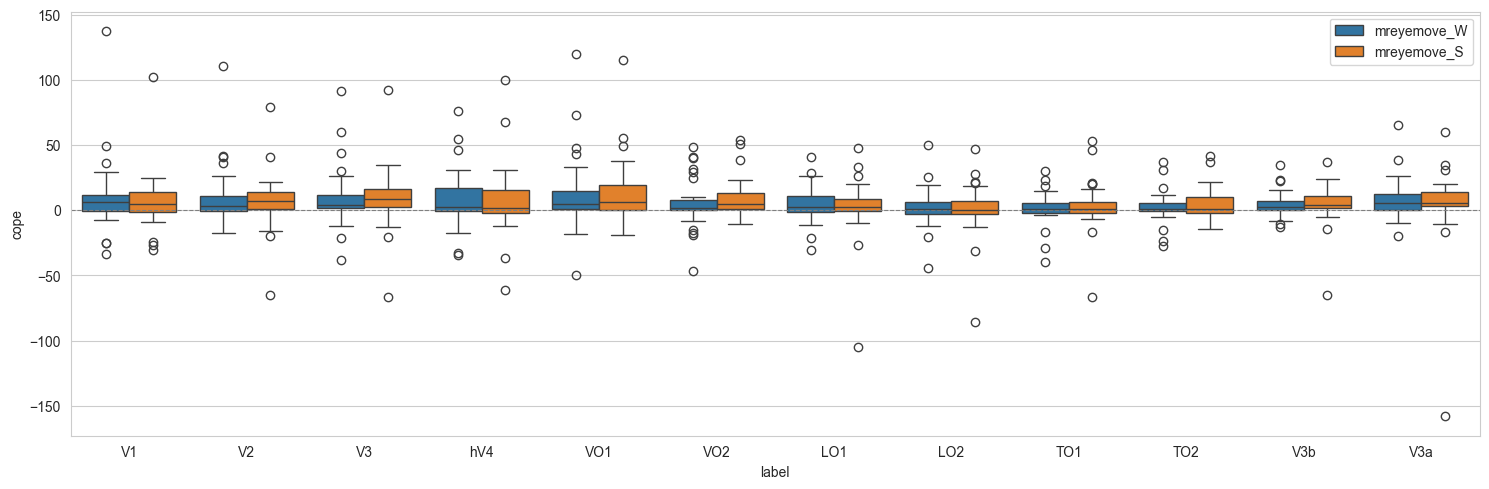

In [86]:
import numpy as np
from matplotlib import pyplot as plt 

out_dir = mrio.roi_test_dir(desc_add=desc_add)
out_dir.mkdir(parents=True, exist_ok=True)
roi_data_path = out_dir / f"benson_roi_run_data.tsv"
df = pd.read_csv(roi_data_path, sep="\t")

import seaborn as sns

cared_for_contrasts = ["mreyemove_W", "mreyemove_S"]
# cared_for_order = ["V1", "V2", "V3"]
# keep only the two contrasts you want to compare
sub = df[df["contrast"].isin(cared_for_contrasts)]

plt.figure(figsize=(15, 5))
sns.boxplot(
    data=sub,
    x="label", y="cope", hue="contrast",
    # order=cared_for_order,
    hue_order=cared_for_contrasts,
)
plt.axhline(0, color="grey", lw=0.8, ls="--")   # optional t=0 reference
plt.ylabel("cope")
plt.legend()
plt.tight_layout()
plt.show()


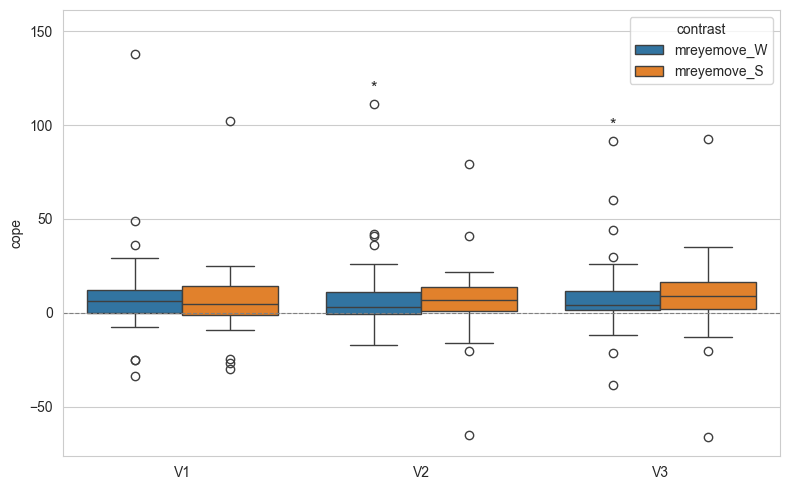

In [78]:
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

# significance table (your df with t_stat / p_val / p_fdr)
stats_df = pd.read_csv("/Users/zach/2025_RA/matthias/bids_sleepmreye/derivatives/mreyemove/group/func/glm_brain/roi_lme/desc-clean-original-sleep-flame/roi_test_results_copes.tsv", sep="\t")

cared_for_contrasts = ["mreyemove_W", "mreyemove_S"]
cared_for_order = ["V1", "V2", "V3"]
# keep only the two contrasts you want to compare
sub = df[df["contrast"].isin(cared_for_contrasts)]

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=sub,
    x="label", y="cope", hue="contrast",
    order=cared_for_order,
    hue_order=cared_for_contrasts,
)
ax.axhline(0, color="grey", lw=0.8, ls="--")
ax.set_ylabel("cope"); ax.set_xlabel("")

# --- significance lookup (FDR-corrected; switch to "p_val" if you want uncorrected) ---
pcol = "p_fdr"
sig = stats_df[(stats_df["contrast"].isin(cared_for_contrasts))]
pmap = {(r.contrast, r.label): getattr(r, pcol) for r in sig.itertuples()}

def stars(p):
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""

# seaborn dodges hue boxes at i + width*(j+0.5)/n - width/2  (default width=0.8)
n, width = len(cared_for_contrasts), 0.8
offsets = [width * (j + 0.5) / n - width / 2 for j in range(n)]   # -> [-0.2, +0.2] for 2 hues

yspan = np.diff(ax.get_ylim())[0]
for i, lab in enumerate(cared_for_order):
    for j, con in enumerate(cared_for_contrasts):
        p = pmap.get((con, lab))
        if p is None or not stars(p):
            continue
        g = sub[(sub["label"] == lab) & (sub["contrast"] == con)]["cope"]
        ax.text(i + offsets[j], g.max() + 0.02 * yspan, stars(p),
                ha="center", va="bottom", fontsize=12)

ax.set_ylim(top=ax.get_ylim()[1] + 0.06 * yspan)   # headroom so top stars don't clip
ax.legend(title="contrast")
fig.tight_layout()
plt.show()

In [57]:

# wide: one row per subject, columns = ROI labels, values = cope
d = {"V1": 1, "V2": -0.5, "V3": -0.5}
wide = df[df["contrast"]=="mreyemove_W"]
w = wide['label'].map(d) 
c = (df['cope'] * w).groupby(df['subject']).sum()
# wide 
c

subject
1     10.603550
3      9.105260
4     -2.216274
5      4.775531
6      1.487574
7     20.267010
8      0.569250
9    -27.140252
10     9.848110
11     2.123044
12    -2.351655
13    -0.886003
14    -1.506614
15   -13.488148
16     4.879516
17    -4.096441
18    -2.418319
19    -0.738343
20    -0.727285
22     6.855373
23   -33.500623
24     3.550835
25    36.438231
26    -0.329412
27    -0.024252
28     3.795941
29     0.154897
30    -5.328856
31   -25.948640
32     0.499549
33     3.090706
dtype: float64

In [99]:

import pandas as pd 
pd.read_csv("/Users/zach/2025_RA/matthias/bids_sleepmreye/derivatives/mreyemove/group/func/glm_brain/roi_lme/desc-clean-original-flame/roi_test_results_tscores.tsv", sep="\t").sort_values(by=["contrast", "label"])

,contrast,atlas,label,t_stat,p_val,n,p_fdr
0,mreyemove,benson,V1,3.243746,0.001500,31,0.001500
1,mreyemove,benson,V2,4.093441,0.000150,31,0.000300
2,mreyemove,benson,V3,4.126254,0.000200,31,0.000300
3,mreyemove_1,benson,V1,2.614814,0.012649,31,0.012649
4,mreyemove_1,benson,V2,3.287542,0.002400,31,0.003600
5,mreyemove_1,benson,V3,3.446510,0.001250,31,0.003600
6,mreyemove_1-mreyemove_2,benson,V1,0.937437,0.358282,25,0.549773
7,mreyemove_1-mreyemove_2,benson,V2,0.605380,0.549773,25,0.549773
8,mreyemove_1-mreyemove_2,benson,V3,0.650305,0.515824,25,0.549773
9,mreyemove_2,benson,V1,0.385019,0.698215,25,0.698215


In [79]:
import pandas as pd 
pd.read_csv("/Users/zach/2025_RA/matthias/bids_sleepmreye/derivatives/mreyemove/group/func/glm_brain/roi_lme/desc-clean-original-sleep-flame/roi_test_results_copes.tsv", sep="\t").sort_values(by=["contrast", "label"])

,contrast,atlas,label,t_stat,p_val,n,p_fdr
0,mreyemove,benson,V1,1.868867,0.007700,31,0.007700
1,mreyemove,benson,V2,2.476130,0.000300,31,0.000900
2,mreyemove,benson,V3,2.638746,0.001900,31,0.002850
3,mreyemove_S,benson,V1,1.648085,0.089996,31,0.091195
4,mreyemove_S,benson,V2,1.755504,0.091195,31,0.091195
5,mreyemove_S,benson,V3,1.979291,0.047648,31,0.091195
6,mreyemove_W,benson,V1,1.798341,0.056097,31,0.056097
7,mreyemove_W,benson,V2,2.141751,0.019499,31,0.029249
8,mreyemove_W,benson,V3,2.349926,0.018049,31,0.029249
9,mreyemove_W-mreyemove_S,benson,V1,0.287737,0.777211,31,0.897605


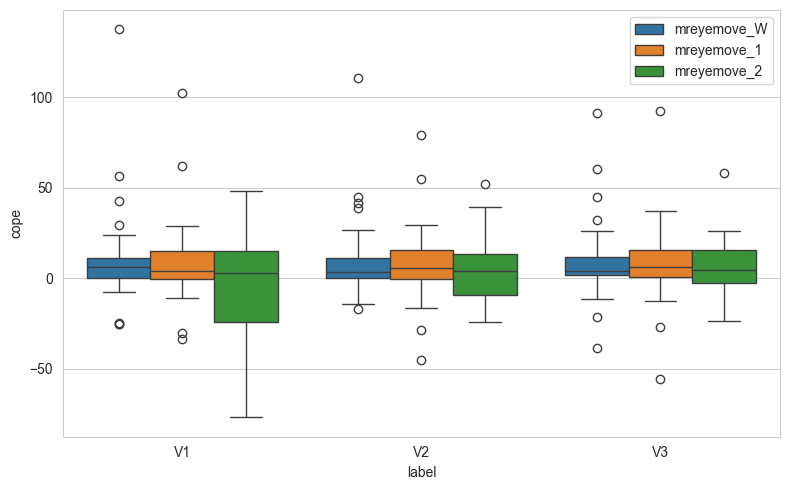

In [69]:
import numpy as np
from matplotlib import pyplot as plt 

roi_data_path = "/Users/zach/2025_RA/matthias/bids_sleepmreye/derivatives/mreyemove/group/func/glm_brain/roi_lme/desc-clean-original-flame/benson_roi_run_data.tsv"
df = pd.read_csv(roi_data_path, sep="\t")

import seaborn as sns

cared_for_contrasts = ["mreyemove_W", "mreyemove_1", "mreyemove_2"]
# keep only the two contrasts you want to compare
sub = df[df["contrast"].isin(cared_for_contrasts)]
cared_for_order = ["V1", "V2", "V3"]

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=sub,
    x="label", y="cope", hue="contrast",
    hue_order=cared_for_contrasts,
    order=cared_for_order,
)
# plt.axhline(0, color="grey", lw=0.8, ls="--")   # optional t=0 reference
plt.ylabel("cope")
plt.legend()
plt.tight_layout()
plt.show()

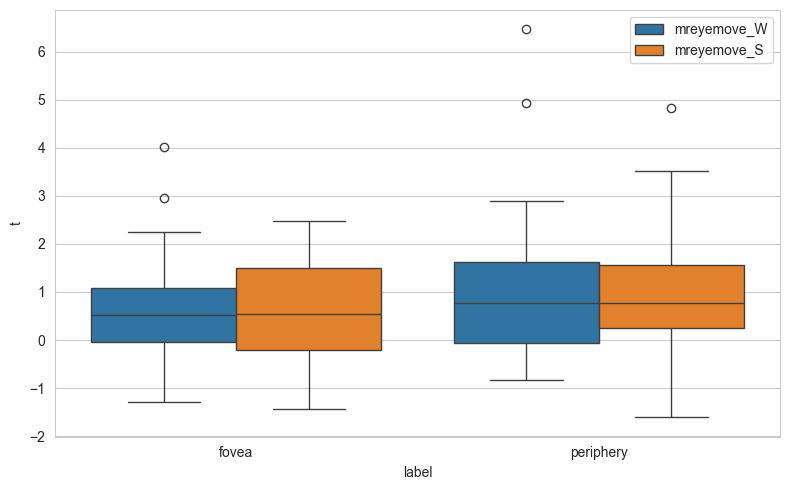

,contrast,atlas,label,t_stat,p_val,n,p_fdr
0,mreyemove,benson_eccen,fovea,3.283528,0.001700,31,0.001700
1,mreyemove,benson_eccen,periphery,4.363948,0.000150,31,0.000300
2,mreyemove_S,benson_eccen,fovea,3.111852,0.003550,31,0.003550
3,mreyemove_S,benson_eccen,periphery,4.029952,0.000300,31,0.000600
4,mreyemove_W,benson_eccen,fovea,3.007912,0.003700,31,0.003700
5,mreyemove_W,benson_eccen,periphery,3.843941,0.000250,31,0.000500
6,mreyemove_W-mreyemove_S,benson_eccen,fovea,-0.673435,0.506875,31,0.506875
7,mreyemove_W-mreyemove_S,benson_eccen,periphery,-0.889439,0.379531,31,0.506875


In [20]:
stat = ("tscores", "t")
import pandas as pd 
summ_df = pd.read_csv(f"/Users/zach/2025_RA/matthias/bids_sleepmreye/derivatives/mreyemove/group/func/glm_brain/roi_lme/desc-clean-original-sleep-flame/benson_eccen_roi_test_results_{stat[0]}.tsv", sep="\t").sort_values(by=["contrast", "label"])


import numpy as np
from matplotlib import pyplot as plt 

roi_data_path = "/Users/zach/2025_RA/matthias/bids_sleepmreye/derivatives/mreyemove/group/func/glm_brain/roi_lme/desc-clean-original-sleep-flame/benson_eccen_roi_run_data.tsv"
df = pd.read_csv(roi_data_path, sep="\t")

import seaborn as sns

cared_for_contrasts = ["mreyemove_W", "mreyemove_S"]
# keep only the two contrasts you want to compare
sub = df[df["contrast"].isin(cared_for_contrasts)]

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=sub,
    x="label", y=stat[1], hue="contrast",
    order=["fovea", "periphery"],
    hue_order=cared_for_contrasts,
)
# plt.axhline(0, color="grey", lw=0.8, ls="--")   # optional t=0 reference
plt.ylabel(stat[1])
plt.legend()
plt.tight_layout()
plt.show()

summ_df

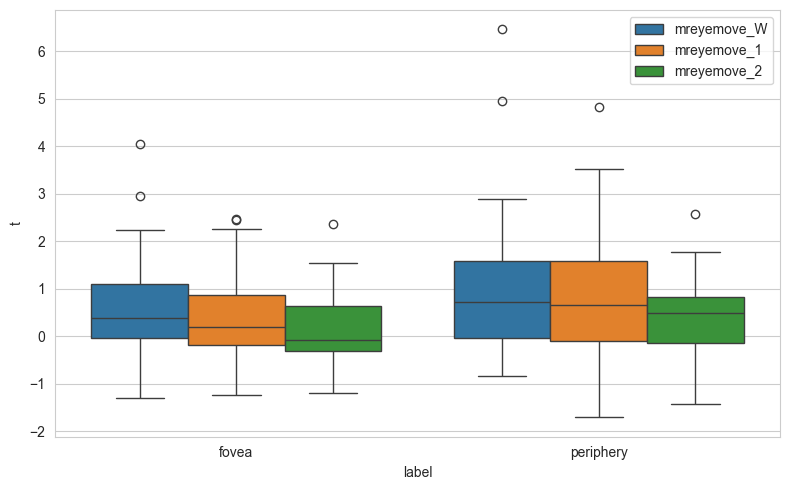

,contrast,atlas,label,t_stat,p_val,n,p_fdr
0,mreyemove,benson_eccen,fovea,3.163773,0.002600,31,0.002600
1,mreyemove,benson_eccen,periphery,4.251632,0.000100,31,0.000200
2,mreyemove_1,benson_eccen,fovea,2.533495,0.014799,31,0.014799
3,mreyemove_1,benson_eccen,periphery,3.451107,0.001200,31,0.002400
4,mreyemove_1-mreyemove_2,benson_eccen,fovea,0.619111,0.539373,25,0.592820
5,mreyemove_1-mreyemove_2,benson_eccen,periphery,0.537814,0.592820,25,0.592820
6,mreyemove_2,benson_eccen,fovea,1.075473,0.297935,25,0.297935
7,mreyemove_2,benson_eccen,periphery,2.123177,0.044298,25,0.088596
8,mreyemove_W,benson_eccen,fovea,2.975363,0.003500,31,0.003500
9,mreyemove_W,benson_eccen,periphery,3.838154,0.000100,31,0.000200


In [23]:
# stat = ("copes", "cope")
stat = ("tscores", "t")
import pandas as pd 
summ_df = pd.read_csv(f"/Users/zach/2025_RA/matthias/bids_sleepmreye/derivatives/mreyemove/group/func/glm_brain/roi_lme/desc-clean-original-flame/benson_eccen_roi_test_results_{stat[0]}.tsv", sep="\t").sort_values(by=["contrast", "label"])


import numpy as np
from matplotlib import pyplot as plt 

roi_data_path = "/Users/zach/2025_RA/matthias/bids_sleepmreye/derivatives/mreyemove/group/func/glm_brain/roi_lme/desc-clean-original-flame/benson_eccen_roi_run_data.tsv"
df = pd.read_csv(roi_data_path, sep="\t")

import seaborn as sns

cared_for_contrasts = ["mreyemove_W", "mreyemove_1", "mreyemove_2"]
# keep only the two contrasts you want to compare
sub = df[df["contrast"].isin(cared_for_contrasts)]

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=sub,
    x="label", y=stat[1], hue="contrast",
    order=["fovea", "periphery"],
    hue_order=cared_for_contrasts,
)
# plt.axhline(0, color="grey", lw=0.8, ls="--")   # optional t=0 reference
plt.ylabel(stat[1])
plt.legend()
plt.tight_layout()
plt.show()

summ_df

In [80]:
from mreyemove.analysis.glm.atlas import fetch_atlas

atlas = fetch_atlas("benson")


for name in atlas.labels:
    print(f'"{name}": [{name}]')

[load_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
"Background": [Background]
"V1": [V1]
"V2": [V2]
"V3": [V3]
"hV4": [hV4]
"VO1": [VO1]
"VO2": [VO2]
"LO1": [LO1]
"LO2": [LO2]
"TO1": [TO1]
"TO2": [TO2]
"V3b": [V3b]
"V3a": [V3a]
